### Healthcare payment analysis
* Goal: Analysis of gender based payment disparity in pharmaceutical industry
* Scope General data - Top level healthcare business payment analysis
* Date: 19 November 2024

In [ ]:
import pandas as pd
import numpy as np
import sys
# (was required for python setup on OOD cluster)
#! pip install --upgrade pandas 
#! pip install --upgrade numpy
#! pip install --upgrade SciPy


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('Master_data_general_clean_26th_oct_with_gender.csv', low_memory=False)


In [4]:
df.head()


,Unnamed: 0,Covered_Recipient_Type,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,...,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Program_Year,Payment_Publication_Date,Covered_Recipient_gender
0,0,Covered Recipient Physician,NaN,287788.0,sy,le,TX,United States,Medical Doctor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,06/28/2024,M
1,1,Covered Recipient Physician,NaN,271599.0,james,bass,TX,United States,Medical Doctor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,06/28/2024,M
2,2,Covered Recipient Physician,NaN,336633.0,peter,brandon,WA,United States,Medical Doctor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,06/28/2024,M
3,3,Covered Recipient Physician,NaN,1095727.0,leo,brancazio,NC,United States,Medical Doctor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,06/28/2024,M
4,4,Covered Recipient Physician,NaN,1256215.0,karri,chinn,WA,United States,Medical Doctor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,06/28/2024,F


# After clean up 73 columns were retained to keep a flexible approach in the analysis.

In [5]:
df_columns=df.columns

l1=list(enumerate(df_columns))
for i,j in l1:
    print(j)
    

Unnamed: 0
Covered_Recipient_Type
Teaching_Hospital_Name
Covered_Recipient_Profile_ID
Covered_Recipient_First_Name
Covered_Recipient_Last_Name
Recipient_State
Recipient_Country
Covered_Recipient_Primary_Type_1
Covered_Recipient_Primary_Type_2
Covered_Recipient_Primary_Type_3
Covered_Recipient_Primary_Type_4
Covered_Recipient_Primary_Type_5
Covered_Recipient_Primary_Type_6
Covered_Recipient_Specialty_1
Covered_Recipient_Specialty_2
Covered_Recipient_Specialty_3
Covered_Recipient_Specialty_4
Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country
Total_Amount_of_Payment_USDollars
Date_of_Payment
Number_of_Payments_Included_in_Total_Amount
Form_of_Payment_or_Transfer_of_Value
Nature_of_Payment_or_Transfer_of_Value
City_of_Travel
State_of_Travel
Country_of_Travel
Physician_Ownership_Indicator
Third_Pa

In [ ]:
df= df.drop(['Unnamed: 0'],axis=1)
df= df.drop(['Program_Year','Payment_Publication_Date','Record_ID'], axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14609233 entries, 0 to 14609232
Data columns (total 73 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Unnamed: 0                                                         int64  
 1   Covered_Recipient_Type                                             object 
 2   Teaching_Hospital_Name                                             object 
 3   Covered_Recipient_Profile_ID                                       float64
 4   Covered_Recipient_First_Name                                       object 
 5   Covered_Recipient_Last_Name                                        object 
 6   Recipient_State                                                    object 
 7   Recipient_Country                                                  object 
 8   Covered_Recipient_Primary_Type_1                                   object 
 9   

In [2]:
df['Covered_Recipient_Profile_ID']=df['Covered_Recipient_Profile_ID'].astype(object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14609233 entries, 0 to 14609232
Data columns (total 69 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Covered_Recipient_Type                                             object 
 1   Teaching_Hospital_Name                                             object 
 2   Covered_Recipient_Profile_ID                                       object 
 3   Covered_Recipient_First_Name                                       object 
 4   Covered_Recipient_Last_Name                                        object 
 5   Recipient_State                                                    object 
 6   Recipient_Country                                                  object 
 7   Covered_Recipient_Primary_Type_1                                   object 
 8   Covered_Recipient_Primary_Type_2                                   object 
 9   

In [10]:
df.describe()

,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount
count,1.460923e+07,1.460923e+07
mean,2.250662e+02,1.016294e+00
std,4.122229e+04,5.482408e-01
min,1.000000e-02,1.000000e+00
25%,1.470000e+01,1.000000e+00
50%,1.945000e+01,1.000000e+00
75%,2.748000e+01,1.000000e+00
max,8.837730e+07,6.400000e+02


In [11]:
df.describe(include=object)

,Covered_Recipient_Type,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,Covered_Recipient_Primary_Type_3,...,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Associated_Drug_or_Biological_NDC_4,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Covered_Recipient_gender
count,14609233,30584,14578649.0,14578233,14577969,14608622,14609233,14578649,1261,670,...,290232,201357,77297,135545,135473,135413,135137,83317,44737,14578233
unique,3,1202,934451.0,76633,231716,59,32,12,5,2,...,1112,221,1043,2,4,275,654,112,674,2
top,Covered Recipient Physician,hospital of the univ of penna,232968.0,michael,patel,TX,United States,Medical Doctor,Nurse Practitioner,Clinical Nurse Specialist,...,aristada,65757-404-03,00852454006257,Covered,Drug,cns,lybalvi,65757-652-42,05694310961134,M
freq,9603554,676,1159.0,251584,101330,1393687,14608622,7915394,723,666,...,61717,61717,11880,134728,70230,61717,56721,56721,9233,7840388


## Top level view of payments and recipients

In [12]:
# Total amount and number of transactions
print("Total payments processed in the year 2023:" , df['Total_Amount_of_Payment_USDollars'].sum())
print("total number of transactions processed in 2023:", df['Number_of_Payments_Included_in_Total_Amount'].sum())

Total payments processed in the year 2023: 3288045175.6800013
total number of transactions processed in 2023: 14847270


In [13]:
# Number of individuals paid using profile ID
print("The number of individuals paid:", df['Covered_Recipient_Profile_ID'].nunique())

The number of individuals paid: 934451


In [14]:
# Number of third parites reciving payments
print("Number of third parties receiving payments", df['Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value'].nunique())


Number of third parties receiving payments 12561


In [15]:
# Check number of third parties reciving payments.
df['Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value'].describe()

count                         97208
unique                        12561
top       hyatt regency jersey city
freq                            907
Name: Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value, dtype: object

In [16]:
# Charity based transactions
df['Charity_Indicator'].value_counts(dropna=False)

Charity_Indicator
NaN    10484306
No      4124697
Yes         230
Name: count, dtype: int64

In [17]:
print("Amount paid in charity")
df[df['Charity_Indicator']=='Yes']['Total_Amount_of_Payment_USDollars'].sum()

Amount paid in charity


2811811.0700000003

In [18]:
df[df['Charity_Indicator']=='Yes'].describe(include=object)

,Covered_Recipient_Type,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Recipient_State,Recipient_Country,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,Covered_Recipient_Primary_Type_3,...,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Associated_Drug_or_Biological_NDC_4,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Covered_Recipient_gender
count,230,61,169.0,169,169,230,230,169,0,0,...,1,1,0,0,0,0,0,0,0,169
unique,3,42,108.0,87,106,35,1,6,0,0,...,1,1,0,0,0,0,0,0,0,2
top,Covered Recipient Physician,uc davis medical center,863244.0,jeffrey,carter,LA,United States,Medical Doctor,NaN,NaN,...,vyzulta,24208-504-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
freq,163,3,23.0,25,23,25,230,141,NaN,NaN,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126


# The payers information

In [19]:
# Paying entities the manufacturers and GPO

print("The number of Manufacture or GPO making payment:", df['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'].nunique())

print("The number of submitting manufacture or GPO:", df['Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name'].nunique())



The number of Manufacture or GPO making payment: 1698
The number of submitting manufacture or GPO: 1614


In [20]:
# Sorting by top payers 
top_payers=df.groupby('Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_payers

,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Total_Amount_of_Payment_USDollars
0,biontech se,3.678493e+08
1,abbvie inc.,1.871323e+08
2,"zimmer biomet holdings, inc.",1.284672e+08
3,stryker corporation,1.190687e+08
4,"medtronic, inc.",1.175617e+08
...,...,...
1693,"tek medical, llc",3.300000e+01
1694,imactis inc,2.398000e+01
1695,"integrated commercialization solutions, llc",1.803000e+01
1696,"kvk-tech, inc.",1.583000e+01


In [21]:
## data for documentation
top_payers.to_csv('Top_payers_general.csv')

### Recipient types

In [22]:
# All the covered recipient types
df['Covered_Recipient_Type'].unique()

array(['Covered Recipient Physician',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Teaching Hospital'], dtype=object)

In [23]:
df['Covered_Recipient_Type'].value_counts()

Covered_Recipient_Type
Covered Recipient Physician                     9603554
Covered Recipient Non-Physician Practitioner    4975095
Covered Recipient Teaching Hospital               30584
Name: count, dtype: int64

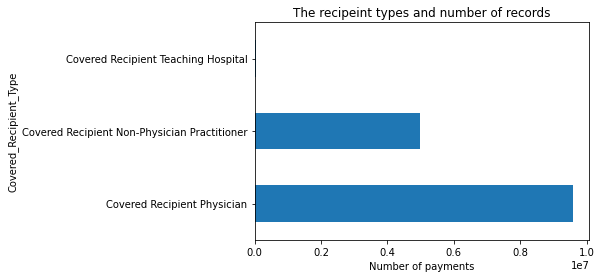

In [24]:
# Covered recipient types and numer of payment records
plt.title('The recipeint types and number of records');
df['Covered_Recipient_Type'].value_counts().plot(kind='barh')
plt.xlabel('Number of payments');


In [25]:
# Recipient types and total amount pain to each type
df.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().reset_index()

,Covered_Recipient_Type,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,2.091875e+08
1,Covered Recipient Physician,2.285636e+09
2,Covered Recipient Teaching Hospital,7.932218e+08


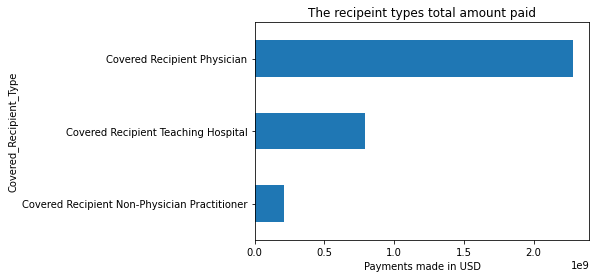

In [26]:
# Covered recipient types and payment amount

plt.title('The recipeint types total amount paid');
df.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().sort_values().plot(kind='barh')
plt.xlabel('Payments made in USD');

In [27]:
# Payment to teaching hospitals
print("The number of teaching hospitals paid:", df['Teaching_Hospital_Name'].nunique())

The number of teaching hospitals paid: 1202


In [28]:
# Teaching hospitals and related paymants
top_teaching=df.groupby(['Covered_Recipient_Type', 'Teaching_Hospital_Name'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_teaching.Covered_Recipient_Type.describe()


count                                    1202
unique                                      1
top       Covered Recipient Teaching Hospital
freq                                     1202
Name: Covered_Recipient_Type, dtype: object

In [29]:
# Teaching hospitals sorted by total payment amount
print("Teaching hospitals and total payments")
top_teaching

,Covered_Recipient_Type,Teaching_Hospital_Name,Total_Amount_of_Payment_USDollars
0,Covered Recipient Teaching Hospital,hospital of the univ of penna,3.776336e+08
1,Covered Recipient Teaching Hospital,dana-farber cancer institute,8.569233e+07
2,Covered Recipient Teaching Hospital,massachusetts general hospital,4.043933e+07
3,Covered Recipient Teaching Hospital,cleveland clinic hospital,2.565962e+07
4,Covered Recipient Teaching Hospital,univ of mi hospitals & hlth ctrs,2.313702e+07
...,...,...,...
1197,Covered Recipient Teaching Hospital,kennedy university hospital,1.571000e+01
1198,Covered Recipient Teaching Hospital,monroe clinic,1.309000e+01
1199,Covered Recipient Teaching Hospital,beaumont hospital - taylor,1.295000e+01
1200,Covered Recipient Teaching Hospital,cobb hospital and medical center,1.275000e+01


In [30]:
top_teaching.to_csv("general_teaching_payments.csv")

### Gender distribution

In [31]:
# identifying unique individuals using profile ID.
print("Total individuals by profile paid:", df['Covered_Recipient_Profile_ID'].nunique())



Total individuals by profile paid: 934451


In [32]:
print("Gender distribution in healthcare dataset")
gender_dist=df.groupby(['Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist

Gender distribution in healthcare dataset


,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,F,464728
1,M,470719


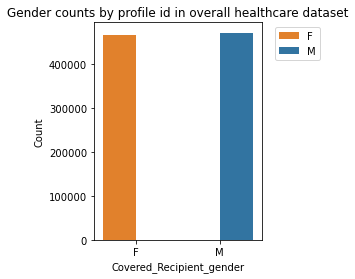

In [33]:
# Plot for gender distribution
my_palette ={"F": "C1", "M": "C0"}
g=sns.barplot(data=gender_dist, x='Covered_Recipient_gender', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender counts by profile id in overall healthcare dataset")
g.figure.set_size_inches(3, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.xticks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


### At top level the gender ratio is not skewed, when we consider all the profiles together

In [34]:
## Verifying in teaching hospitals
print("Gender distribution by physicians and non-physicians in teaching hospitals")
print(df[df['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'].groupby(['Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index())

df[df['Covered_Recipient_Type']=='Covered Recipient Teaching Hospital'].groupby(['Covered_Recipient_Profile_ID'])['Covered_Recipient_gender'].nunique().reset_index()


Gender distribution by physicians and non-physicians in teaching hospitals
Empty DataFrame
Columns: [Covered_Recipient_gender, Covered_Recipient_Profile_ID]
Index: []


,Covered_Recipient_Profile_ID,Covered_Recipient_gender


### No individuals associated to teaching hospoitals

### The covered recipients gender split, profile ID sanity checks

In [35]:
print("Gender distribution by physicians and non-physicians in Covered recipients")
gender_dist_recipients=df.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_recipients



Gender distribution by physicians and non-physicians in Covered recipients


,Covered_Recipient_Type,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Covered Recipient Non-Physician Practitioner,F,246019
1,Covered Recipient Non-Physician Practitioner,M,63510
2,Covered Recipient Physician,F,221755
3,Covered Recipient Physician,M,408100


In [36]:
# profile IDs with more than one name
(df.groupby('Covered_Recipient_Profile_ID').nunique()['Covered_Recipient_First_Name']>1).sum()


8754

In [37]:
# profile IDs with more than one name
(df[df.Covered_Recipient_Type=='Covered Recipient Non-Physician Practitioner'].groupby('Covered_Recipient_Profile_ID').nunique()['Covered_Recipient_First_Name']>1).sum()



1387

In [38]:
# Overlapping profile IDs
(df[df.Covered_Recipient_Type=='Covered Recipient Physician'].groupby('Covered_Recipient_Profile_ID').nunique()['Covered_Recipient_First_Name']>1).sum()



7368

## 8754 IDs have more than 1 name associated. Causing descripencies.

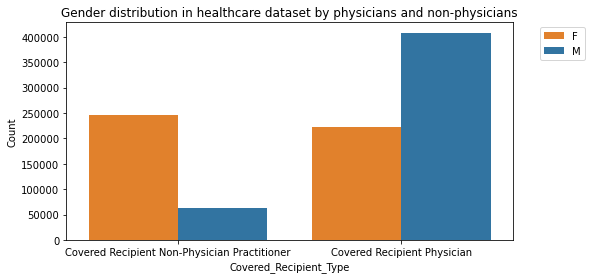

In [39]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_recipients, x='Covered_Recipient_Type', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution in healthcare dataset by physicians and non-physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


### Observation: In Non-Physician the females are higher in number and in physician roles males are higher.

In [40]:
print("Gender distribution amongst physician categories")
gender_dist_physicians=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_physicians


Gender distribution amongst physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Chiropractor,F,405
1,Chiropractor,M,1285
2,Doctor of Dentistry,F,32752
3,Doctor of Dentistry,M,61800
4,Doctor of Optometry,F,17059
5,Doctor of Optometry,M,17444
6,Doctor of Osteopathy,F,25574
7,Doctor of Osteopathy,M,40631
8,Doctor of Podiatric Medicine,F,3754
9,Doctor of Podiatric Medicine,M,9177


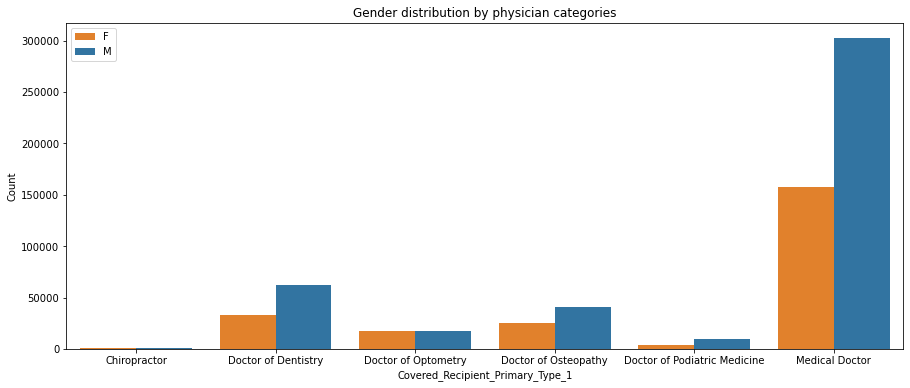

In [41]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by physician categories")
g.figure.set_size_inches(15, 6)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(loc='upper left');


### All physician categories males are higher in number.

In [42]:
print("Gender distribution amongst non-physician categories")
gender_dist_non_physicians=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_non_physicians


Gender distribution amongst non-physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Anesthesiologist Assistant,F,268
1,Anesthesiologist Assistant,M,307
2,Certified Nurse-Midwife,F,3314
3,Certified Nurse-Midwife,M,171
4,Certified Registered Nurse Anesthetist,F,9782
5,Certified Registered Nurse Anesthetist,M,6618
6,Clinical Nurse Specialist,F,3103
7,Clinical Nurse Specialist,M,423
8,Nurse Practitioner,F,178178
9,Nurse Practitioner,M,32710


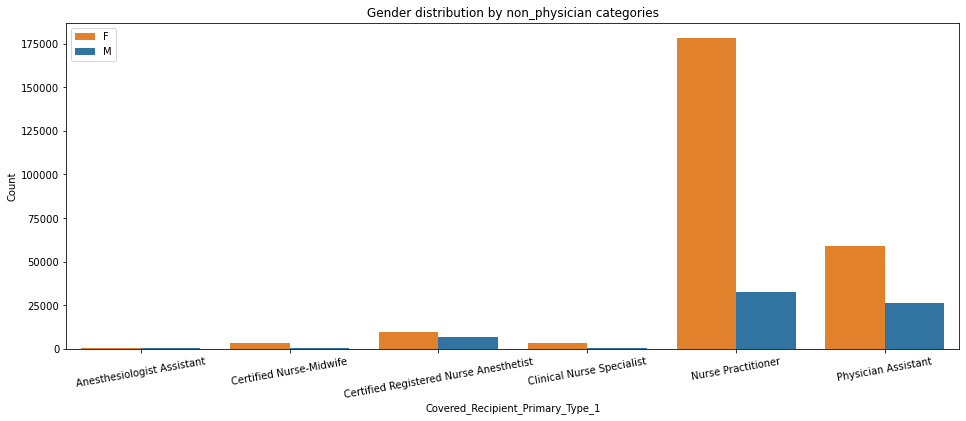

In [43]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_non_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by non_physician categories")
g.figure.set_size_inches(16, 6)
plt.ylabel("Count")
plt.xticks(rotation=10)
# Place the legend outside the plot
plt.legend(loc='upper left');


## All non-physician categories females are higher in number.

### Payment analysis - Total payments 

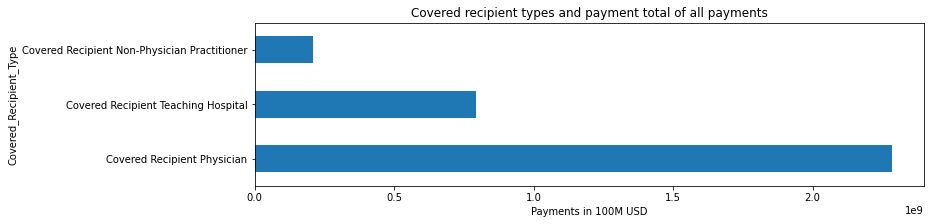

In [44]:
# Covered recipient types and total payments to each type
plt.figure(figsize=(12,3))
plt.title('Covered recipient types and payment total of all payments')
df.groupby(['Covered_Recipient_Type'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Payments in 100M USD");


## Maximum payments are made to  physicians.

In [45]:
# Covered recipient types and total payments to each type by gender
print("Total payments by recipients gender")
recipient_gender_payments=df.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index();

recipient_gender_payments


Total payments by recipients gender


,Covered_Recipient_Type,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Covered Recipient Physician,M,1.918470e+09
1,Covered Recipient Physician,F,3.671409e+08
2,Covered Recipient Non-Physician Practitioner,F,1.642991e+08
3,Covered Recipient Non-Physician Practitioner,M,4.488415e+07


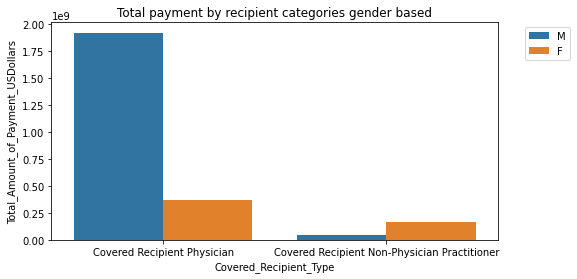

In [46]:
# Plot for gender distribution
g=sns.barplot(data=recipient_gender_payments, x='Covered_Recipient_Type', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by recipient categories gender based")
g.figure.set_size_inches(8, 4)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


**Observation: Total payments are higher for males and count of males is high in physician category, it's opposite in non-physician categories**

In [47]:
### Total payment split physician profiles
print("The total payment for physician profiles")
physicians_total_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Total_Amount_of_Payment_USDollars
0,Medical Doctor,2.050599e+09
1,Doctor of Osteopathy,9.382780e+07
2,Doctor of Dentistry,8.314929e+07
3,Doctor of Podiatric Medicine,3.443025e+07
4,Doctor of Optometry,2.331873e+07
5,Chiropractor,3.105519e+05


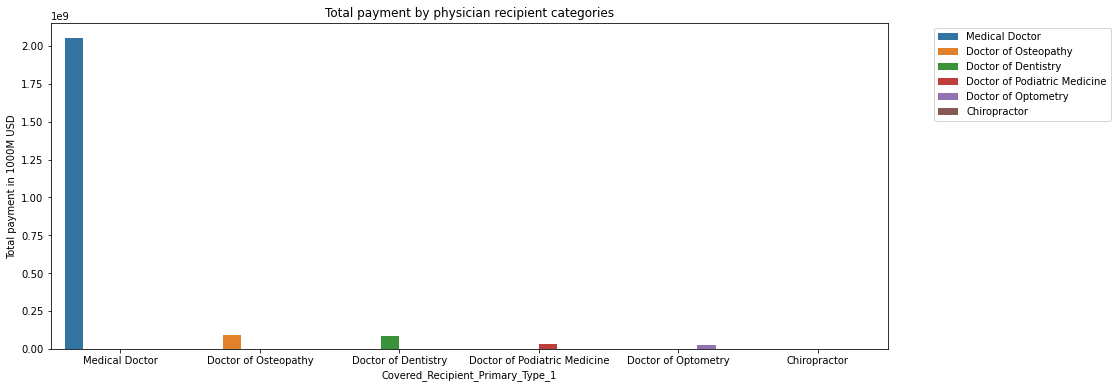

In [48]:
# Plot for recipient physician total payment distribution
g=sns.barplot(data=physicians_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_Primary_Type_1').set_title("Total payment by physician recipient categories")
g.figure.set_size_inches(15, 6)
plt.ylabel("Total payment in 1000M USD")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


### Maximum payment is in 'Medical doctor' category, followed by doctor of osteopathy.

In [49]:
### Total payment split physician profiles by gender
print("The total payment for physician profiles")
physicians_gender_total_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1', 'Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_gender_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Medical Doctor,M,1.735136e+09
1,Medical Doctor,F,3.154404e+08
2,Doctor of Osteopathy,M,7.103212e+07
3,Doctor of Dentistry,M,6.838936e+07
4,Doctor of Podiatric Medicine,M,2.930963e+07
5,Doctor of Osteopathy,F,2.279557e+07
6,Doctor of Dentistry,F,1.475862e+07
7,Doctor of Optometry,M,1.436934e+07
8,Doctor of Optometry,F,8.949389e+06
9,Doctor of Podiatric Medicine,F,5.120607e+06


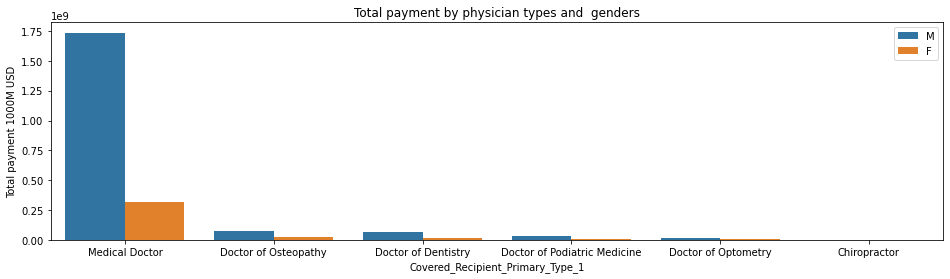

In [50]:
# Plot for gender distribution
g=sns.barplot(data=physicians_gender_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by physician types and  genders")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment 1000M USD")
# Place the legend outside the plot
plt.legend( loc='upper right');


### Total payments for all physician categories are higher in total payments. Note the number is also high.

## Non physician categories

In [51]:
### Total payment split non-physician primary-profiles
print("The total payment for non physician primary profile")
non_physicians_total_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
non_physicians_total_payments


The total payment for non physician primary profile


,Covered_Recipient_Primary_Type_1,Total_Amount_of_Payment_USDollars
0,Nurse Practitioner,1.354927e+08
1,Physician Assistant,6.884338e+07
2,Certified Registered Nurse Anesthetist,2.143111e+06
3,Clinical Nurse Specialist,2.020889e+06
4,Certified Nurse-Midwife,6.440890e+05
5,Anesthesiologist Assistant,4.340697e+04


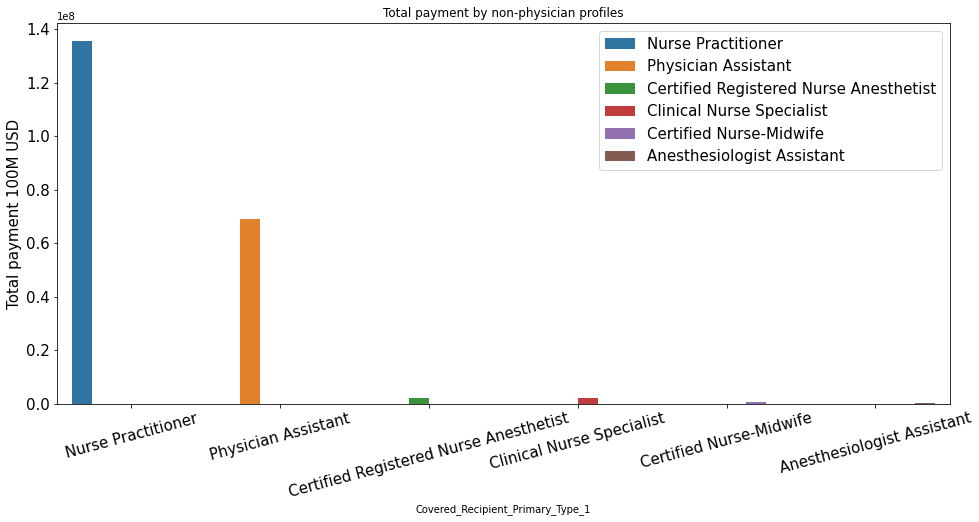

In [52]:
# Plot for payment distribution by primary type for non-physicians
g=sns.barplot(data=non_physicians_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_Primary_Type_1').set_title("Total payment by non-physician profiles")
g.figure.set_size_inches(16,7)
plt.ylabel("Total payment 100M USD", fontsize=15);
# Place the legend outside the plot
plt.legend(fontsize=15, loc='upper right')
plt.xticks(rotation=15, fontsize=15);
plt.yticks( fontsize=15);


### Maximum total payments in non-physician category is for Nurse practitioners, followed by physician assistants

In [53]:
### Total payment split non-physician high-profiles
print("The total payment for non-physician profiles by gender")
non_physicians_gender_total_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
non_physicians_gender_total_payments


The total payment for non-physician profiles by gender


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Nurse Practitioner,F,1.139733e+08
1,Physician Assistant,F,4.689862e+07
2,Physician Assistant,M,2.194473e+07
3,Nurse Practitioner,M,2.151505e+07
4,Clinical Nurse Specialist,F,1.617372e+06
5,Certified Registered Nurse Anesthetist,F,1.168638e+06
6,Certified Registered Nurse Anesthetist,M,9.744627e+05
7,Certified Nurse-Midwife,F,6.275887e+05
8,Clinical Nurse Specialist,M,4.035171e+05
9,Anesthesiologist Assistant,M,2.989593e+04


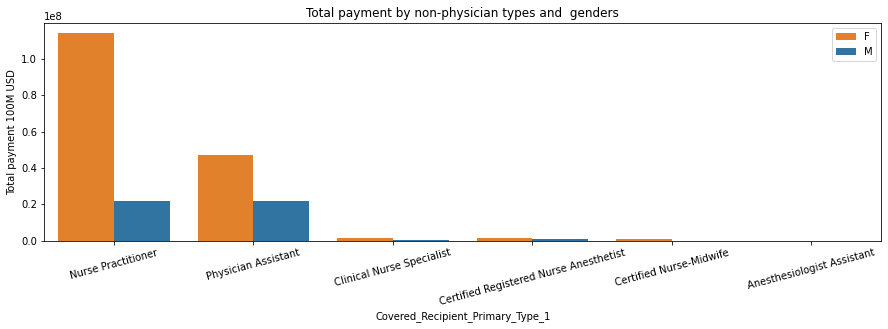

In [54]:
# Plot for gender distribution non physician profiles
g=sns.barplot(data=non_physicians_gender_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by non-physician types and  genders")
g.figure.set_size_inches(15, 4)
plt.ylabel("Total payment 100M USD")
plt.xticks( rotation=15);
# Place the legend outside the plot
plt.legend( loc='upper right');


### Total payments and number of females in non-physician categories are higher.

### Since the distribution is not equal total payment is not fair comparison

#### ***The two columns 'Total_Amount_of_Payment_USDollars', 'Number_of_Payments_Included_in_Total_Amount' to be considered**

In [ ]:
### Average per transaction based. 
df[['Total_Amount_of_Payment_USDollars','Number_of_Payments_Included_in_Total_Amount']].head()

In [55]:
### Average payments
# Since payments have multiple transactions, taking average payment per transaction and creating a new column.
df['Average_payment']=df['Total_Amount_of_Payment_USDollars'].values/df['Number_of_Payments_Included_in_Total_Amount'].values


In [56]:
# Average payment per recipient type.
print("The average payment by per recipient category")
avg=df.groupby(['Covered_Recipient_Type'])['Average_payment'].mean()
avg


The average payment by per recipient category


Covered_Recipient_Type
Covered Recipient Non-Physician Practitioner       41.881439
Covered Recipient Physician                       233.344870
Covered Recipient Teaching Hospital             25737.258621
Name: Average_payment, dtype: float64

In [57]:
avg.describe()

count        3.000000
mean      8670.828310
std      14780.272232
min         41.881439
25%        137.613154
50%        233.344870
75%      12985.301746
max      25737.258621
Name: Average_payment, dtype: float64

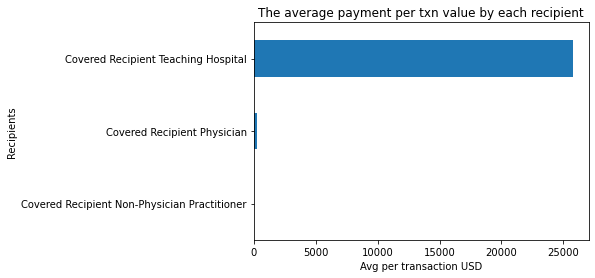

In [58]:
## Plot for average payment per recipient group type
plt.title("The average payment per txn value by each recipient")
avg.plot(kind='barh')
plt.xlabel('Avg per transaction USD')
plt.ylabel('Recipients');


In [59]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average per transaction payment  for recipient types')
gender_recipients_avg=df.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
   
gender_recipients_avg


Gender based average per transaction payment  for recipient types


,Covered_Recipient_Type,Covered_Recipient_gender,Average_payment
0,Covered Recipient Physician,M,275.719804
1,Covered Recipient Physician,F,129.472101
2,Covered Recipient Non-Physician Practitioner,M,43.750812
3,Covered Recipient Non-Physician Practitioner,F,41.400164


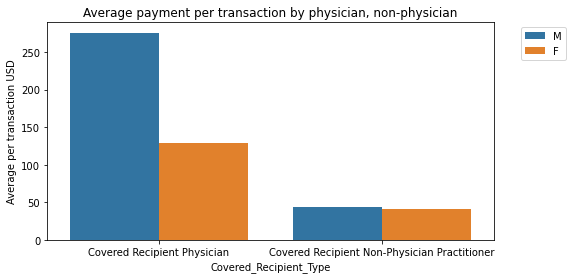

In [60]:
# Plot for gender distribution
g=sns.barplot(data=gender_recipients_avg, x='Covered_Recipient_Type', y='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title("Average payment per transaction by physician, non-physician")
g.figure.set_size_inches(8, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


**Males have higher average per transaction payments overall recipient types**

In [61]:
### Average per txn payment physician profiles
print("The Average per txn payment for each physician categories")
avg_physician_profile=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
avg_physician_profile


The Average per txn payment for each physician categories


,Covered_Recipient_Primary_Type_1,Average_payment
0,Medical Doctor,254.804379
1,Doctor of Podiatric Medicine,219.251271
2,Doctor of Dentistry,217.431283
3,Doctor of Osteopathy,97.751950
4,Doctor of Optometry,94.224049
5,Chiropractor,78.579935


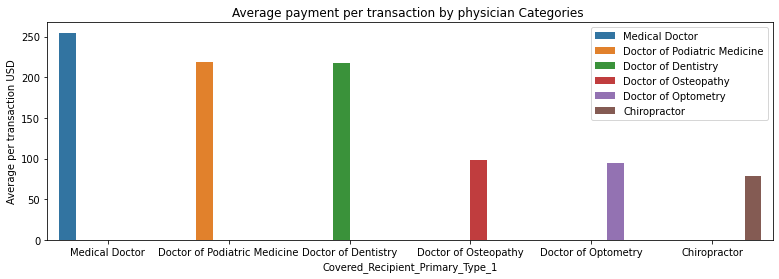

In [62]:
# Plot for gender based average payment per transaction for physician profiles
g=sns.barplot(data=avg_physician_profile, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_Primary_Type_1').set_title("Average payment per transaction by physician Categories ")
g.figure.set_size_inches(13, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
#plt.legend(bbox_to_anchor=(1, 1), loc='upper left');
plt.legend(loc='upper right');


In [63]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average transaction value for physician categories')
gender_recipients_avg_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
gender_recipients_avg_payments


Gender based average transaction value for physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Average_payment
0,Medical Doctor,M,298.980195
1,Doctor of Dentistry,M,261.159972
2,Doctor of Podiatric Medicine,M,251.423807
3,Medical Doctor,F,140.549117
4,Doctor of Podiatric Medicine,F,127.497605
5,Doctor of Dentistry,F,122.480132
6,Doctor of Optometry,M,112.523410
7,Doctor of Osteopathy,M,109.325066
8,Chiropractor,F,83.401201
9,Chiropractor,M,77.084918


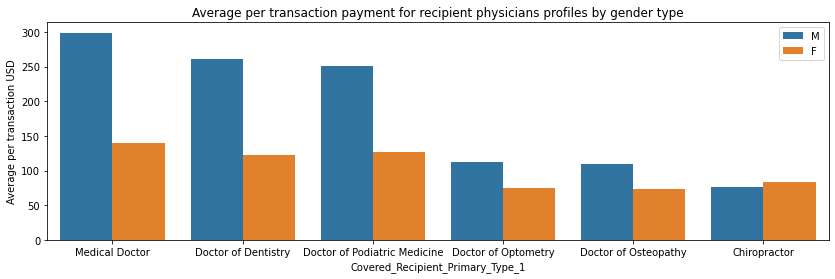

In [64]:
## Plot for average payment per recipient physician primary 1 type
g=sns.barplot(data=gender_recipients_avg_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_gender',palette=my_palette)
g.set_title('Average per transaction payment for recipient physicians profiles by gender type')
g.figure.set_size_inches(14, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend( loc='upper right');


### For male physicians average payment per txn is higher than female physicians ********************

In [65]:
### Total payment split non-physician high-profiles
print("Avg transaction value for non-physician profiles")
non_physicians_avgtxn_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1'])['Average_payment'].mean().sort_values(ascending=False).sort_values(ascending=False).reset_index()
non_physicians_avgtxn_payments


Avg transaction value for non-physician profiles


,Covered_Recipient_Primary_Type_1,Average_payment
0,Clinical Nurse Specialist,72.244188
1,Anesthesiologist Assistant,45.643502
2,Certified Registered Nurse Anesthetist,45.403044
3,Certified Nurse-Midwife,43.996306
4,Physician Assistant,42.360814
5,Nurse Practitioner,41.325288


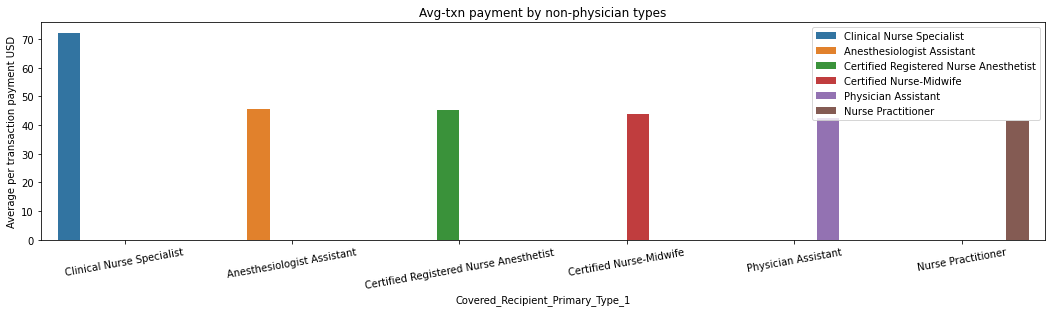

In [66]:
# Plot for gender distribution non physician profiles
g=sns.barplot(data=non_physicians_avgtxn_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_Primary_Type_1').set_title("Avg-txn payment by non-physician types")
g.figure.set_size_inches(18, 4)
plt.ylabel("Average per transaction payment USD")
# Place the legend outside the plot
plt.xticks(rotation=10)
plt.legend(loc='upper right');


In [67]:
### Total payment split non-physician high-profiles
print("Avg transaction value for non-physician profiles by gender")
non_physicians_gender_avgtxn_payments=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).sort_values(ascending=False).reset_index()
non_physicians_gender_avgtxn_payments



Avg transaction value for non-physician profiles by gender


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Average_payment
0,Clinical Nurse Specialist,M,106.314406
1,Clinical Nurse Specialist,F,66.842012
2,Anesthesiologist Assistant,M,54.257586
3,Certified Registered Nurse Anesthetist,M,50.450731
4,Physician Assistant,M,45.634142
5,Certified Nurse-Midwife,F,44.707395
6,Certified Registered Nurse Anesthetist,F,41.909049
7,Nurse Practitioner,F,41.328554
8,Nurse Practitioner,M,41.311169
9,Physician Assistant,F,40.990211


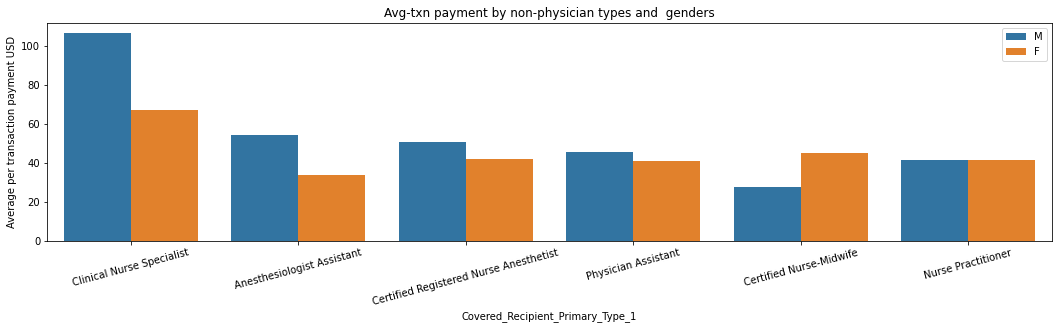

In [68]:
# Plot for gender distribution non physician profiles
g=sns.barplot(data=non_physicians_gender_avgtxn_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title("Avg-txn payment by non-physician types and  genders")
g.figure.set_size_inches(18, 4)
plt.ylabel("Average per transaction payment USD")
# Place the legend outside the plot
plt.xticks(rotation=15)
plt.legend(loc='upper right');


### Statistical analysis by individuals average payments overall

In [69]:
print("individual payment distribution average txn values")
ind_payments=df[df['Covered_Recipient_Profile_ID'].notna()].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Average_payment'].mean().reset_index()
ind_payments



individual payment distribution average txn values


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,3.0,M,19.810000
1,4.0,F,16.412857
2,5.0,M,21.744483
3,6.0,F,19.000000
4,11.0,M,33.180000
...,...,...,...
935442,11566121.0,F,125.000000
935443,11566122.0,F,20.905000
935444,11566123.0,F,13.440000
935445,11566125.0,M,10.906667


In [70]:
ind_payments['Covered_Recipient_Profile_ID']=ind_payments['Covered_Recipient_Profile_ID'].astype(object)

ind_payments.describe()


,Average_payment
count,9.354470e+05
mean,1.943739e+02
std,1.433166e+04
min,1.100000e-01
25%,1.883000e+01
50%,2.543000e+01
75%,6.477029e+01
max,7.322805e+06


In [71]:
ind_payments.describe(include=object)


,Covered_Recipient_Profile_ID,Covered_Recipient_gender
count,935447.0,935447
unique,934409.0,2
top,301855.0,M
freq,2.0,470719


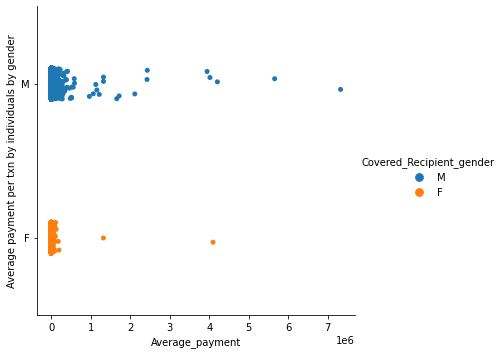

In [72]:
# Plot for gender distribution for all payees
g=sns.catplot(data=ind_payments, y='Covered_Recipient_gender', x='Average_payment', hue='Covered_Recipient_gender',  palette=my_palette)
plt.ylabel("Average payment per txn by individuals by gender");


### Observation: When average payments for each individual is observed, there are lot of outliers. While for males outlier range is up to 7m usd and visually a lot in number. females have two payments 1.2m usd and 4m usd approx. 

# Top payments for non physician individuals

In [73]:
print("individual payment distribution")
ind_payments_nonphys=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Average_payment'].mean().reset_index()
ind_payments_nonphys


individual payment distribution


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,93.0,F,68.462500
1,797.0,M,19.366198
2,834.0,F,25.526364
3,1604.0,M,40.945714
4,2390.0,M,20.517037
...,...,...,...
309524,11566121.0,F,125.000000
309525,11566122.0,F,20.905000
309526,11566123.0,F,13.440000
309527,11566125.0,M,10.906667


In [74]:
ind_payments_nonphys['Covered_Recipient_Profile_ID']=ind_payments_nonphys['Covered_Recipient_Profile_ID'].astype(object)
ind_payments_nonphys.describe()


,Average_payment
count,309529.000000
mean,45.435317
std,167.332486
min,0.790000
25%,18.080000
50%,22.510000
75%,42.925714
max,29051.000000


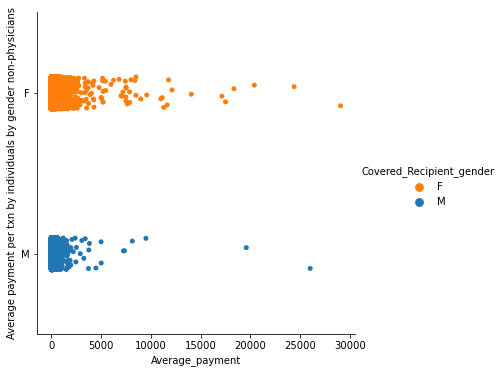

In [75]:
# Plot for gender distribution for non-physicians
g=sns.catplot(data=ind_payments_nonphys, y='Covered_Recipient_gender', x='Average_payment', hue='Covered_Recipient_gender', palette=my_palette)
g.set_titles("{col_name} {col_var}")
plt.ylabel("Average payment per txn by individuals by gender non-physicians");



## The range for females is more than males. females max approx is 30,000USD. For males approx 26,000 USD

## Stats for average payment distribution per female on average transaction values 

#### Note average_payment = average ('Total_Amount_of_Payment_USDollars'/'Number_of_Payments_Included_in_Total_Amount') to be considered


In [76]:
ind_payments_females_non_phys=ind_payments_nonphys[ind_payments_nonphys['Covered_Recipient_gender']=='F'].groupby('Covered_Recipient_Profile_ID')['Average_payment'].mean().reset_index()
ind_payments_females_non_phys.describe()


,Covered_Recipient_Profile_ID,Average_payment
count,2.460190e+05,246019.000000
mean,1.071658e+07,45.762466
std,1.354781e+06,167.342699
min,9.300000e+01,0.790000
25%,1.064046e+07,18.108775
50%,1.090279e+07,22.574762
75%,1.116500e+07,43.754059
max,1.156612e+07,29051.000000


In [77]:
ind_payments_males_non_phys=ind_payments_nonphys[ind_payments_nonphys['Covered_Recipient_gender']=='M'].groupby('Covered_Recipient_Profile_ID')['Average_payment'].mean().reset_index()
ind_payments_males_non_phys.describe()


,Covered_Recipient_Profile_ID,Average_payment
count,6.351000e+04,63510.000000
mean,1.065366e+07,44.168041
std,1.553510e+06,167.288196
min,7.970000e+02,0.790000
25%,1.063258e+07,17.980000
50%,1.089486e+07,22.289565
75%,1.115598e+07,39.941408
max,1.156613e+07,26000.000000


## Mean and Median average txn values are higher for females in non-physician categorty.

## Profiling by individuals average transaction values

In [78]:
top50_nonphys=ind_payments_nonphys.sort_values(by=['Average_payment'], ascending=False).reset_index()[:50]
top50_nonphys



,index,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,6497,5695724.0,F,29051.000000
1,9776,9365031.0,M,26000.000000
2,6251,5690802.0,F,24384.560000
3,113736,10761568.0,F,20390.965000
4,73458,10625753.0,M,19582.270000
5,51292,10550544.0,F,18341.250000
6,164574,10934794.0,F,17500.000000
7,109316,10746771.0,F,17132.500000
8,307389,11555334.0,F,14059.465000
9,189466,11019563.0,F,12126.565000


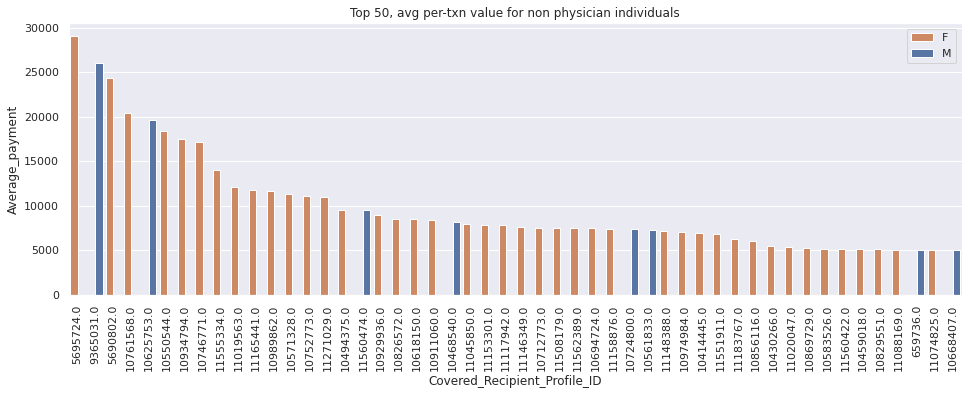

In [79]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=top50_nonphys, x='Covered_Recipient_Profile_ID', y='Average_payment', hue='Covered_Recipient_gender', 
              order=top50_nonphys.sort_values('Average_payment', ascending=False).Covered_Recipient_Profile_ID, palette=my_palette)
g.set(title='Top 50, avg per-txn value for non physician individuals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



## In top 50 there are 8 males in non-physician category

## Top physician individual avg txn payments

In [80]:
print("individual payment distribution")
ind_payments_phys=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Average_payment'].mean().reset_index()
ind_payments_phys



individual payment distribution


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,3.0,M,19.810000
1,4.0,F,16.412857
2,5.0,M,21.744483
3,6.0,F,19.000000
4,11.0,M,33.180000
...,...,...,...
629850,11566021.0,F,2.450000
629851,11566022.0,F,19.180000
629852,11566113.0,M,20.305000
629853,11566118.0,F,83.810000


In [81]:
ind_payments_phys['Covered_Recipient_Profile_ID']=ind_payments_phys['Covered_Recipient_Profile_ID'].astype(object)
ind_payments_phys.describe()



,Average_payment
count,6.298550e+05
mean,2.665616e+02
std,1.746485e+04
min,1.100000e-01
25%,1.932830e+01
50%,2.822000e+01
75%,7.482313e+01
max,7.322805e+06


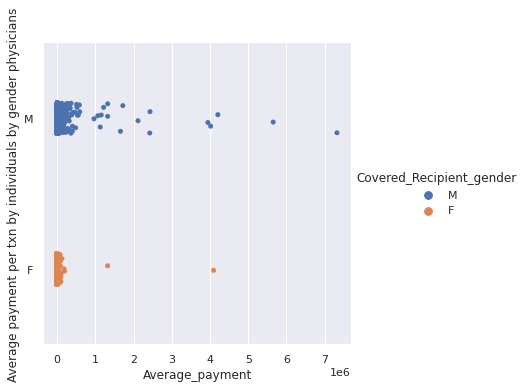

In [82]:
# Plot for gender distribution for physicians
g=sns.catplot(data=ind_payments_phys, y='Covered_Recipient_gender', x='Average_payment', hue='Covered_Recipient_gender', palette=my_palette)
g.set_titles("{col_name} {col_var}")
plt.ylabel("Average payment per txn by individuals by gender physicians");



In [83]:
## Profiling by individuals average transaction values
top50_phys=ind_payments_phys.sort_values(by=['Average_payment'], ascending=False).reset_index()[:50]
top50_phys



,index,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,258128,559457.0,M,7.322805e+06
1,167687,288926.0,M,5.653671e+06
2,405003,1166415.0,M,4.204908e+06
3,276435,635409.0,F,4.095035e+06
4,61339,105583.0,M,4.016379e+06
5,26723,46018.0,M,3.944328e+06
6,258792,562354.0,M,2.429895e+06
7,109207,187955.0,M,2.423330e+06
8,103254,177835.0,M,2.114786e+06
9,165235,284714.0,M,1.717867e+06


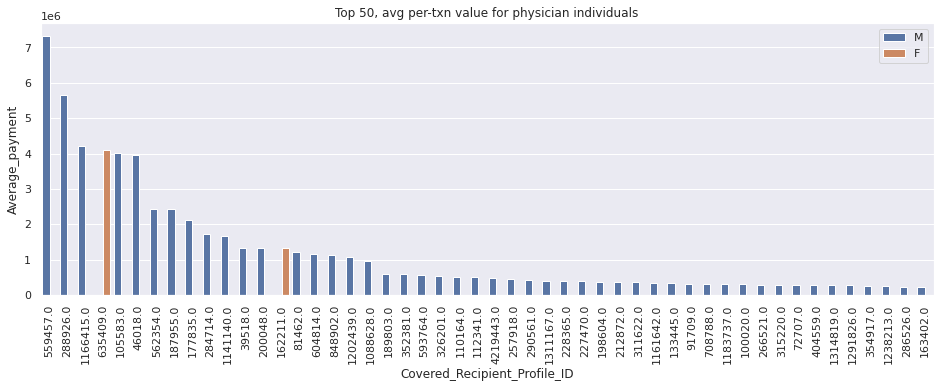

In [84]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=top50_phys, x='Covered_Recipient_Profile_ID', y='Average_payment', hue='Covered_Recipient_gender', 
              order=top50_phys.sort_values('Average_payment', ascending=False).Covered_Recipient_Profile_ID, palette=my_palette)
g.set(title='Top 50, avg per-txn value for physician individuals')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');



In [85]:
top25_males_phys=ind_payments_phys[ind_payments_phys['Covered_Recipient_gender']=='M'].sort_values(by=['Average_payment'], ascending=False).reset_index()[:25]
top25_males_phys


,index,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,258128,559457.0,M,7.322805e+06
1,167687,288926.0,M,5.653671e+06
2,405003,1166415.0,M,4.204908e+06
3,61339,105583.0,M,4.016379e+06
4,26723,46018.0,M,3.944328e+06
5,258792,562354.0,M,2.429895e+06
6,109207,187955.0,M,2.423330e+06
7,103254,177835.0,M,2.114786e+06
8,165235,284714.0,M,1.717867e+06
9,398857,1141140.0,M,1.657189e+06


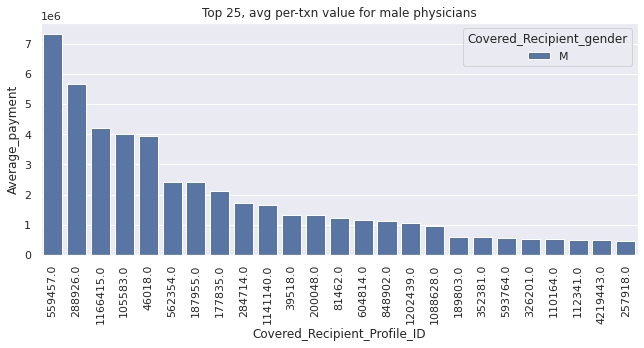

In [86]:
sns.set_theme(rc={'figure.figsize':(10.7,4.27)})
g=sns.barplot(data=top25_males_phys, x='Covered_Recipient_Profile_ID', y='Average_payment', 
              order=top25_males_phys.sort_values('Average_payment', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette)
g.set(title='Top 25, avg per-txn value for male physicians')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
#Place the legend outside the plot
#plt.legend(loc='upper right');


In [87]:
top25_females_phys=ind_payments_phys[ind_payments_phys['Covered_Recipient_gender']=='F'].sort_values(by=['Average_payment'], ascending=False).reset_index()[:25]
top25_females_phys


,index,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Average_payment
0,276435,635409.0,F,4.095035e+06
1,94125,162211.0,F,1.319781e+06
2,410595,1189512.0,F,1.940468e+05
3,140573,242330.0,F,1.764050e+05
4,425609,1252285.0,F,1.250000e+05
5,338751,892736.0,F,1.070750e+05
6,261659,574017.0,F,9.771695e+04
7,530537,6352389.0,F,9.750000e+04
8,581620,11305976.0,F,9.000000e+04
9,609343,11448144.0,F,8.932900e+04


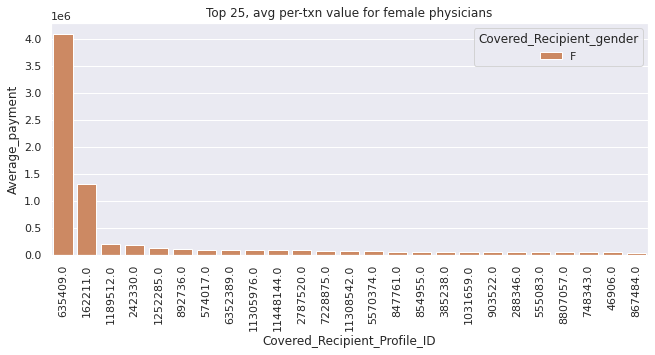

In [88]:
sns.set_theme(rc={'figure.figsize':(10.7,4.27)})
g=sns.barplot(data=top25_females_phys, x='Covered_Recipient_Profile_ID', y='Average_payment', 
              order=top25_females_phys.sort_values('Average_payment', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette)
g.set(title='Top 25, avg per-txn value for female physicians')
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
# plt.legend(loc='upper right');


## A deep dive into physician categories

## Covered recipient physicians & non-physicians categories check - if they can have multiple types.

#### No individual recipients associated with teaching school payments in this data.

In [89]:
## The recipient primary type 1
df['Covered_Recipient_Primary_Type_1'].value_counts()


Covered_Recipient_Primary_Type_1
Medical Doctor                            7915394
Nurse Practitioner                        3266216
Physician Assistant                       1618674
Doctor of Osteopathy                       941772
Doctor of Dentistry                        350087
Doctor of Optometry                        243643
Doctor of Podiatric Medicine               148788
Certified Registered Nurse Anesthetist      47183
Clinical Nurse Specialist                   27678
Certified Nurse-Midwife                     14393
Chiropractor                                 3870
Anesthesiologist Assistant                    951
Name: count, dtype: int64

In [90]:
## The primary recipient type 1 amongst physicians
print("The covered physicians types")
df[df['Covered_Recipient_Type']=='Covered Recipient Physician']['Covered_Recipient_Primary_Type_2'].value_counts()


The covered physicians types


Series([], Name: count, dtype: int64)

In [91]:
## The primary recipient type 1 amongst physicians
print("The covered physicians types")
df[df['Covered_Recipient_Type']=='Covered Recipient Physician']['Covered_Recipient_Primary_Type_3'].value_counts()


The covered physicians types


Series([], Name: count, dtype: int64)

In [92]:
## The primary recipient type 1 amongst physicians
print("The covered physicians types")
df[df['Covered_Recipient_Type']=='Covered Recipient Physician']['Covered_Recipient_Primary_Type_4'].value_counts()


The covered physicians types


Series([], Name: count, dtype: int64)

In [93]:
## The primary recipient type 1 amongst physicians
print("The covered physicians types")
df[df['Covered_Recipient_Type']=='Covered Recipient Physician']['Covered_Recipient_Primary_Type_5'].value_counts()


The covered physicians types


Series([], Name: count, dtype: int64)

In [94]:
## The primary recipient type 1 amongst physicians
print("The covered physicians types")
df[df['Covered_Recipient_Type']=='Covered Recipient Physician']['Covered_Recipient_Primary_Type_6'].value_counts()


The covered physicians types


Series([], Name: count, dtype: int64)

### All physician profiles are covered in Covered_Recipient_Primary_Type_1 and have 1 primary speciality.

## Covered recipient non-physicians profile check

In [95]:
# The non-physician practitioner primary 1 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_1'].value_counts()


Covered_Recipient_Primary_Type_1
Nurse Practitioner                        3266216
Physician Assistant                       1618674
Certified Registered Nurse Anesthetist      47183
Clinical Nurse Specialist                   27678
Certified Nurse-Midwife                     14393
Anesthesiologist Assistant                    951
Name: count, dtype: int64

In [96]:
# The non-physician practitioner primary 2 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_2'].value_counts()


Covered_Recipient_Primary_Type_2
Nurse Practitioner                        723
Clinical Nurse Specialist                 276
Certified Nurse-Midwife                   140
Certified Registered Nurse Anesthetist    119
Anesthesiologist Assistant                  3
Name: count, dtype: int64

In [97]:
# The non-physician practitioner primary 3 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_3'].value_counts()


Covered_Recipient_Primary_Type_3
Clinical Nurse Specialist                 666
Certified Registered Nurse Anesthetist      4
Name: count, dtype: int64

In [98]:
# The non-physician practitioner primary 4 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_4'].value_counts()


Covered_Recipient_Primary_Type_4
Certified Registered Nurse Anesthetist    666
Name: count, dtype: int64

In [99]:
# The non-physician practitioner primary 5 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_5'].value_counts()


Covered_Recipient_Primary_Type_5
Certified Nurse-Midwife    666
Name: count, dtype: int64

In [100]:
# The non-physician practitioner primary 6 types
df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner']['Covered_Recipient_Primary_Type_6'].value_counts()


Covered_Recipient_Primary_Type_6
Anesthesiologist Assistant    666
Name: count, dtype: int64

In [101]:
clean_df=df[df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'][['Covered_Recipient_Profile_ID','Covered_Recipient_Primary_Type_1',
                'Covered_Recipient_Primary_Type_2','Covered_Recipient_Primary_Type_3', 'Covered_Recipient_Primary_Type_4',
                                'Covered_Recipient_Primary_Type_5', 'Covered_Recipient_Primary_Type_6']].dropna()

clean_df

,Covered_Recipient_Profile_ID,Covered_Recipient_Primary_Type_1,Covered_Recipient_Primary_Type_2,Covered_Recipient_Primary_Type_3,Covered_Recipient_Primary_Type_4,Covered_Recipient_Primary_Type_5,Covered_Recipient_Primary_Type_6
12416466,10744549.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12416467,11263080.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12416468,10536645.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12416471,10893922.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12416472,10909492.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
...,...,...,...,...,...,...,...
12426393,10954849.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12426397,11140059.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12427033,10869597.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant
12427034,10909492.0,Physician Assistant,Nurse Practitioner,Clinical Nurse Specialist,Certified Registered Nurse Anesthetist,Certified Nurse-Midwife,Anesthesiologist Assistant


In [102]:
clean_df.Covered_Recipient_Profile_ID.value_counts()

Covered_Recipient_Profile_ID
11001982.0    73
10744549.0    62
11170076.0    42
10488249.0    41
11263080.0    41
              ..
11065266.0     1
9774450.0      1
271048.0       1
10639937.0     1
10624491.0     1
Name: count, Length: 128, dtype: int64

### 128 non -physician profiles are associated with all Covered_Recipient_Primary_Type 1,2,3,4,5,6 in 666 records

### we have considered only primary 1 for analysis

# Form of payments

In [103]:
# Forms of payments and number of transactions
print("Number of payment records by form of payment")
df.Form_of_Payment_or_Transfer_of_Value.value_counts()

Number of payment records by form of payment


Form_of_Payment_or_Transfer_of_Value
In-kind items and services                        12573826
Cash or cash equivalent                            2034989
Stock option                                           198
Stock                                                  131
Any other ownership interest                            50
Dividend, profit or other return on investment          39
Name: count, dtype: int64

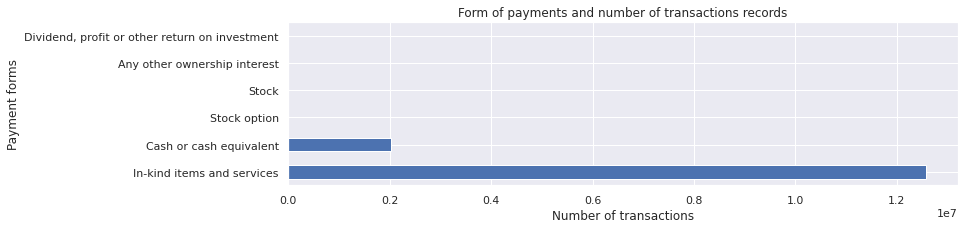

In [104]:
# Form of payments and number of transactions
plt.figure(figsize=(12,3))
plt.title('Form of payments and number of transactions records')
df.Form_of_Payment_or_Transfer_of_Value.value_counts().plot(kind='barh')
plt.xlabel("Number of transactions");
plt.ylabel("Payment forms");


In [105]:
# Form of payments and total payments to each type
print("Form of payments and total payments of each type")
df.groupby(['Form_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False)


Form of payments and total payments of each type


Form_of_Payment_or_Transfer_of_Value
Cash or cash equivalent                           2.703444e+09
In-kind items and services                        5.543721e+08
Stock option                                      1.174059e+07
Stock                                             1.173354e+07
Dividend, profit or other return on investment    6.091368e+06
Any other ownership interest                      6.635647e+05
Name: Total_Amount_of_Payment_USDollars, dtype: float64

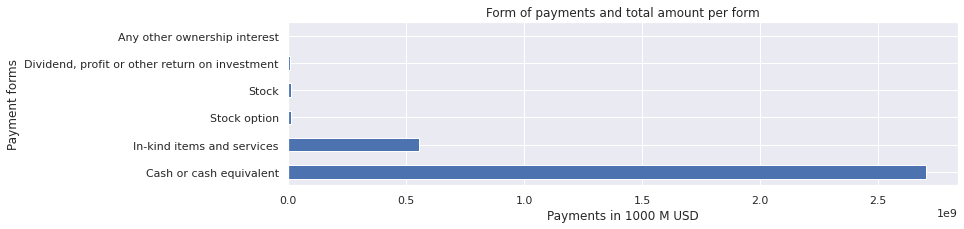

In [106]:
# Form of payments and total payments to each type
plt.figure(figsize=(12,3))
plt.title('Form of payments and total amount per form')
df.groupby(['Form_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Payments in 1000 M USD")
plt.ylabel("Payment forms");


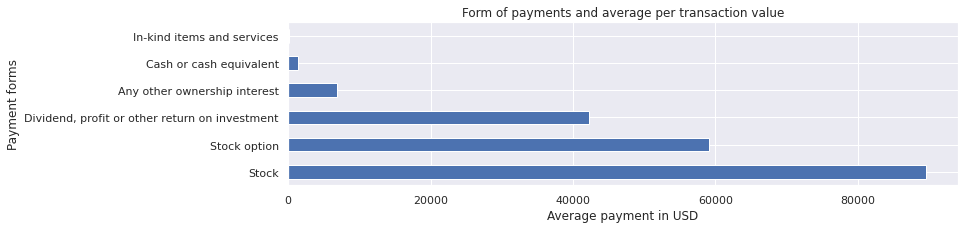

In [107]:
# Form of payments and average transaction value of each type
plt.figure(figsize=(12,3))
plt.title('Form of payments and average per transaction value')
df.groupby(['Form_of_Payment_or_Transfer_of_Value'])['Average_payment'].mean().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Average payment in USD")
plt.ylabel("Payment forms");


###  Form of payments across recipients and gender

In [108]:
# Form of payments and total amount for recipient types
total_form=df.groupby(['Covered_Recipient_Type','Form_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()



In [109]:
total_form

,Covered_Recipient_Type,Form_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Covered Recipient Physician,Cash or cash equivalent,1.865124e+09
1,Covered Recipient Teaching Hospital,Cash or cash equivalent,7.497686e+08
2,Covered Recipient Physician,In-kind items and services,3.903864e+08
3,Covered Recipient Non-Physician Practitioner,In-kind items and services,1.206315e+08
4,Covered Recipient Non-Physician Practitioner,Cash or cash equivalent,8.855100e+07
5,Covered Recipient Teaching Hospital,In-kind items and services,4.335421e+07
6,Covered Recipient Physician,Stock option,1.174059e+07
7,Covered Recipient Physician,Stock,1.163454e+07
8,Covered Recipient Physician,"Dividend, profit or other return on investment",6.091368e+06
9,Covered Recipient Physician,Any other ownership interest,6.585647e+05


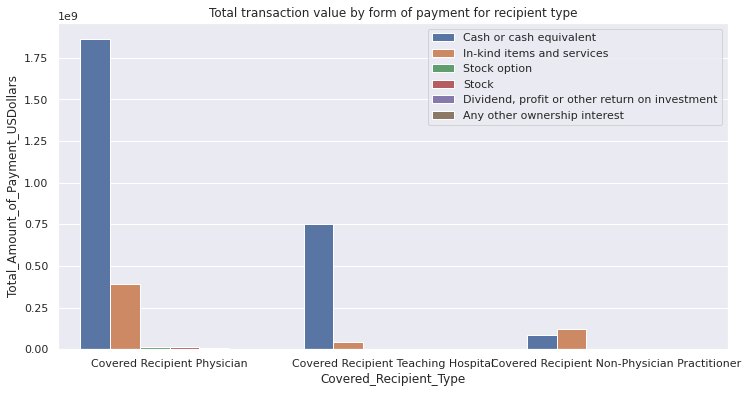

In [110]:
# Average transaction value by Form of payments.
g=sns.barplot(data=total_form, x ='Covered_Recipient_Type', y ='Total_Amount_of_Payment_USDollars', hue='Form_of_Payment_or_Transfer_of_Value').set_title('Total transaction value by form of payment for recipient type')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right');


In [111]:
# Form of payments and average transaction value for recipient types
total_form_gender=df.groupby(['Covered_Recipient_Type','Covered_Recipient_gender','Form_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().reset_index()
total_form_gender


,Covered_Recipient_Type,Covered_Recipient_gender,Form_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,F,Cash or cash equivalent,6.863046e+07
1,Covered Recipient Non-Physician Practitioner,F,In-kind items and services,9.566859e+07
2,Covered Recipient Non-Physician Practitioner,M,Any other ownership interest,5.000000e+03
3,Covered Recipient Non-Physician Practitioner,M,Cash or cash equivalent,1.992012e+07
4,Covered Recipient Non-Physician Practitioner,M,In-kind items and services,2.495903e+07
5,Covered Recipient Physician,F,Any other ownership interest,2.003502e+05
6,Covered Recipient Physician,F,Cash or cash equivalent,2.610096e+08
7,Covered Recipient Physician,F,"Dividend, profit or other return on investment",6.242214e+05
8,Covered Recipient Physician,F,In-kind items and services,1.000021e+08
9,Covered Recipient Physician,F,Stock,1.482886e+06


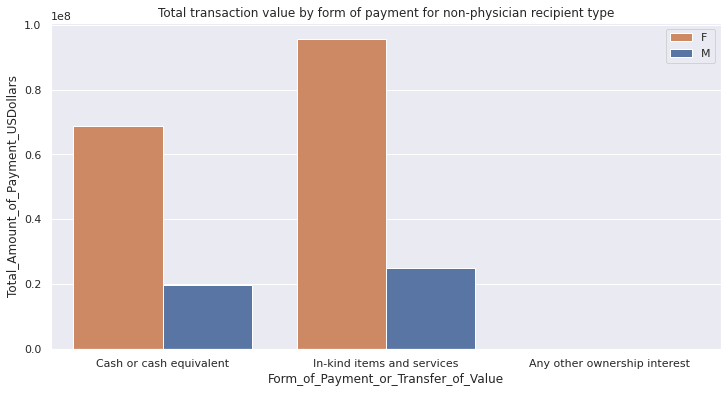

In [112]:
# Average transaction value by Form of payments & gender

g=sns.barplot(data=total_form_gender[total_form_gender['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'], y ='Total_Amount_of_Payment_USDollars', x='Form_of_Payment_or_Transfer_of_Value',hue='Covered_Recipient_gender', palette=my_palette).set_title('Total transaction value by form of payment for non-physician recipient type')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right');
    

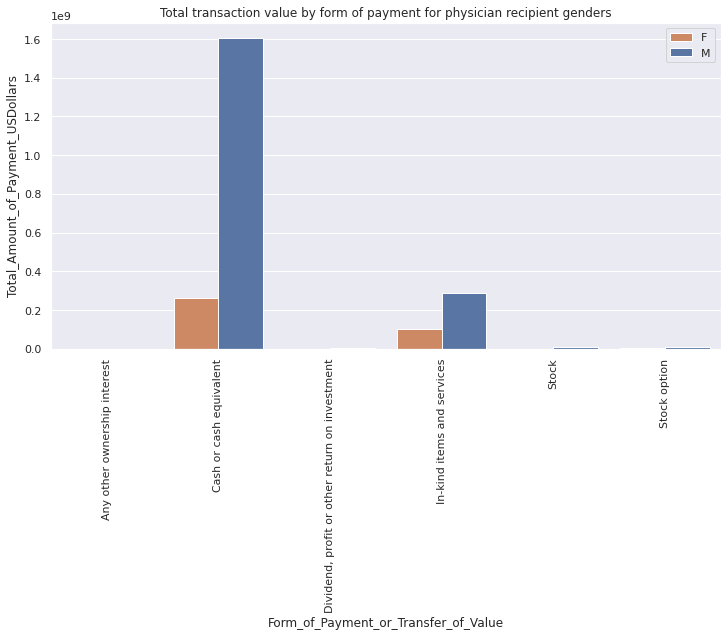

In [113]:
# Average transaction value by Form of payments & gender

g=sns.barplot(data=total_form_gender[total_form_gender['Covered_Recipient_Type']=='Covered Recipient Physician'], y ='Total_Amount_of_Payment_USDollars', x='Form_of_Payment_or_Transfer_of_Value',hue='Covered_Recipient_gender', palette=my_palette).set_title('Total transaction value by form of payment for physician recipient genders')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);
    

## Form of payments for  physicians ( stocks, stock options, ownership & interests, cash & equivalent, in kind services, dividend profit or other roi.)

In [114]:
# Total csh or cash equivalent by Form of payments for individuals.
tot_form_cash=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')& (df['Form_of_Payment_or_Transfer_of_Value']=='Cash or cash equivalent')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
tot_form_cash


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,288926.0,M,33922024.93
1,1166415.0,M,29433942.06
2,311622.0,M,17304476.15
3,105583.0,M,16065515.51
4,1141140.0,M,11600124.00
...,...,...,...
268873,88073.0,M,0.81
268874,1035727.0,M,0.58
268875,986221.0,M,0.56
268876,4227554.0,M,0.42


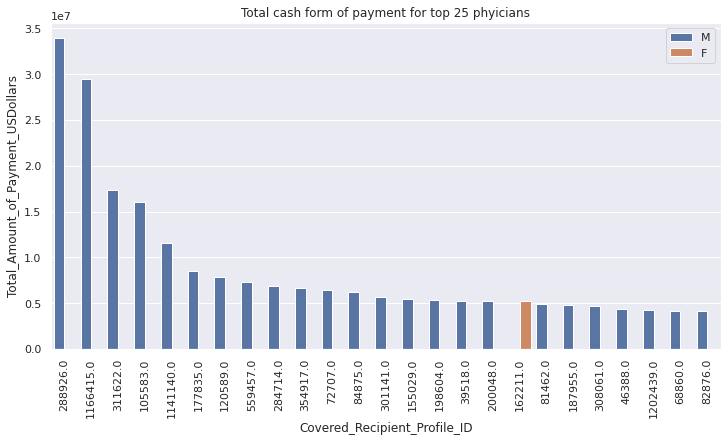

In [115]:
# Total csh or cash equivalent by Form of payments for individuals.
g=sns.barplot(data=tot_form_cash[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=tot_form_cash[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total cash form of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [116]:
# Ownership & interests Form of payments for individuals.
phys_tot_form_ownership_int=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Form_of_Payment_or_Transfer_of_Value']=='Any other ownership interest')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_form_ownership_int


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,260004.0,M,331000.00
1,396552.0,F,199983.84
2,39890.0,M,54301.01
3,295991.0,M,14150.00
4,239736.0,M,13970.00
5,270585.0,M,12977.10
6,375467.0,M,12850.00
7,117471.0,M,8250.00
8,151817.0,M,5000.00
9,228895.0,M,1700.00


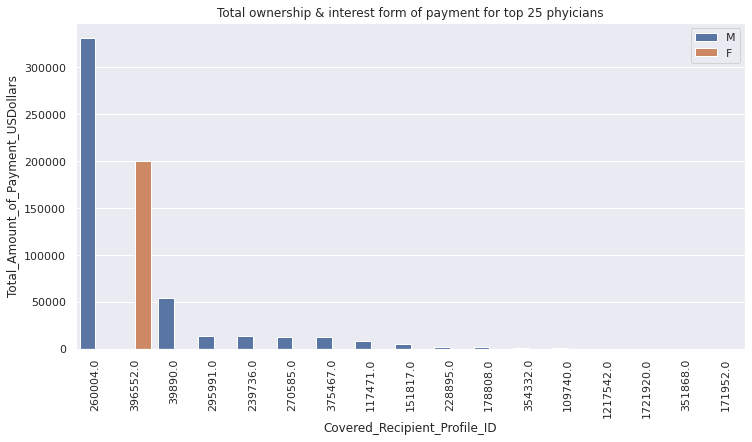

In [117]:
# Ownership & interests Form of payments for individuals.
g=sns.barplot(data=phys_tot_form_ownership_int[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_form_ownership_int[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total ownership & interest form of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [118]:
# In-kind items and services
phys_tot_form_kind_services=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Form_of_Payment_or_Transfer_of_Value']=='In-kind items and services')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_form_kind_services



,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,848902.0,M,4507382.07
1,214322.0,M,530600.09
2,233626.0,M,286077.66
3,334495.0,M,254396.23
4,13702.0,M,254339.29
...,...,...,...
574481,226321.0,F,0.79
574482,56951.0,M,0.79
574483,863088.0,M,0.35
574484,595337.0,F,0.35


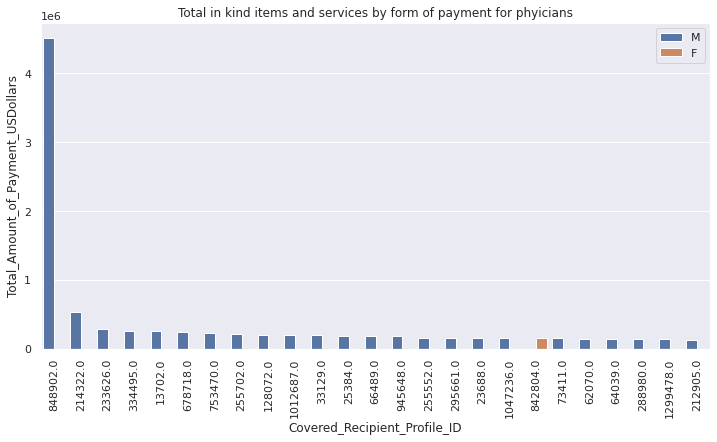

In [119]:
# In kind items & services
g=sns.barplot(data=phys_tot_form_kind_services[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_form_kind_services[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total in kind items and services by form of payment for phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [120]:
# Stocks
phys_tot_form_stock=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Form_of_Payment_or_Transfer_of_Value']=='Stock')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_form_stock


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,67491.0,M,1787710.29
1,315220.0,M,1061488.00
2,1332048.0,M,509570.87
3,203831.0,M,468663.73
4,1347922.0,M,461994.60
...,...,...,...
87,276416.0,M,600.60
88,11313768.0,M,600.60
89,158724.0,M,500.00
90,118341.0,M,500.00


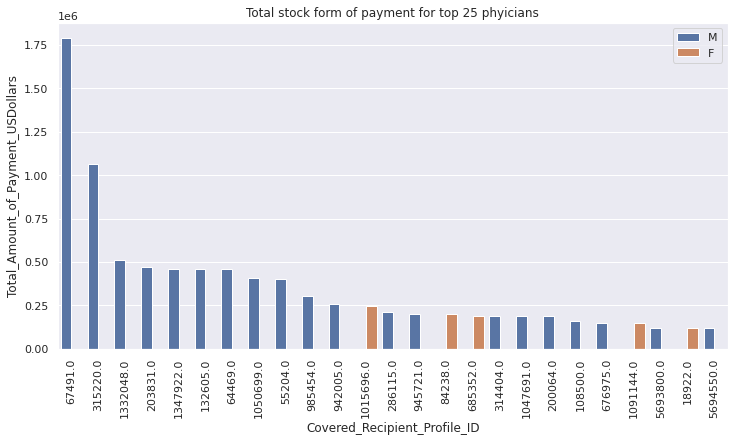

In [121]:
# Total stock by Form of payments for individuals.
g=sns.barplot(data=phys_tot_form_stock[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_form_stock[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total stock form of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [122]:
# Total Stock options for individuals
phys_tot_form_stock_option=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Form_of_Payment_or_Transfer_of_Value']=='Stock option')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_form_stock_option


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,1050699.0,M,1069702.09
1,18922.0,F,480215.26
2,5694550.0,M,480215.26
3,5693800.0,M,480215.26
4,46906.0,F,451822.99
...,...,...,...
124,1041356.0,M,480.00
125,754812.0,M,406.61
126,318303.0,M,400.00
127,80327.0,F,101.40


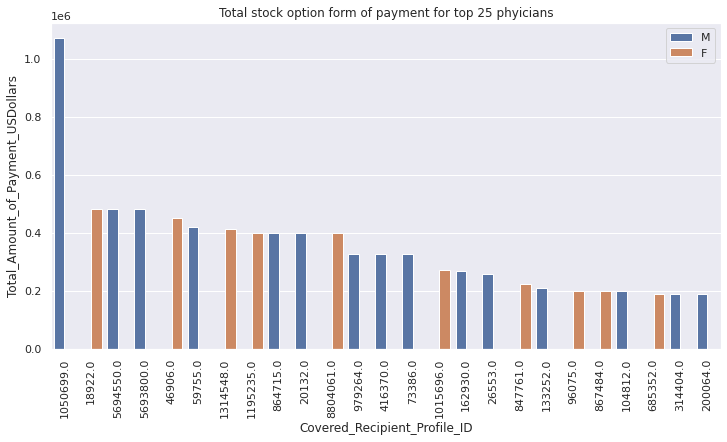

In [123]:
# Stock options value by Form of payments for individuals.
g=sns.barplot(data=phys_tot_form_stock_option[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_form_stock_option[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total stock option form of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [124]:
# dividends, profits or other roi.
phys_tot_form_profit_roi=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Form_of_Payment_or_Transfer_of_Value']=='Dividend, profit or other return on investment')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_form_profit_roi


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,28479.0,F,624221.41
1,333280.0,M,624221.41
2,167424.0,M,624221.41
3,149271.0,M,624221.41
4,118341.0,M,361872.33
5,5703.0,M,312976.00
6,282444.0,M,312976.00
7,61170.0,M,312976.00
8,361376.0,M,310711.65
9,245560.0,M,290000.00


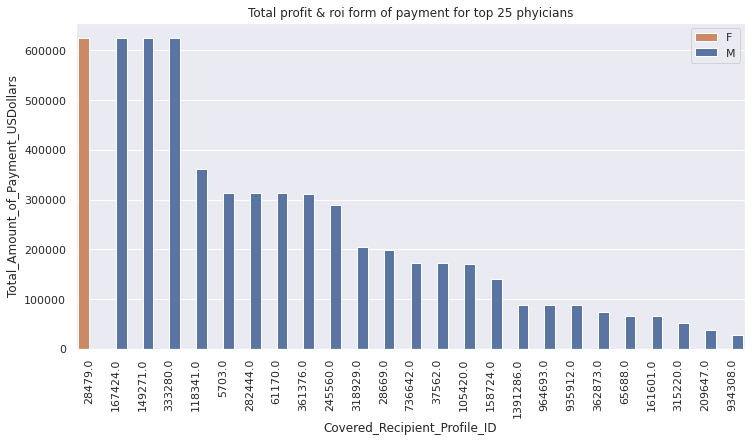

In [125]:
# dividends, profits or other roi.
g=sns.barplot(data=phys_tot_form_profit_roi[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_form_profit_roi[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total profit & roi form of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);

# Average per txn values by form of payments

In [126]:
recip_avg_form=df.groupby(['Covered_Recipient_Type', 'Form_of_Payment_or_Transfer_of_Value', 'Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
                                                                                                                            

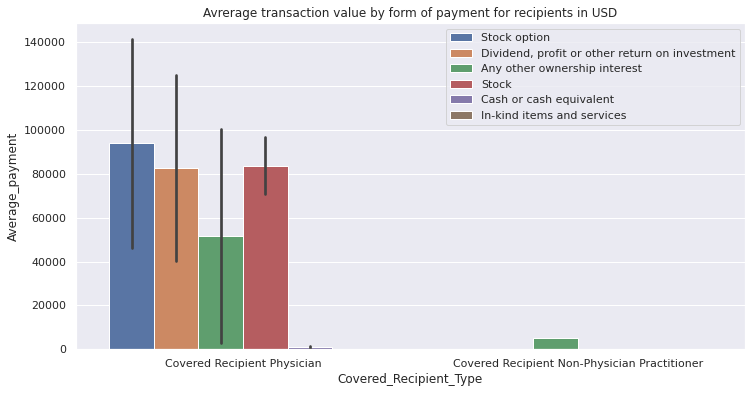

In [127]:
# Average transaction value by Form of payments.
g=sns.barplot(data=recip_avg_form, x ='Covered_Recipient_Type', y ='Average_payment', hue='Form_of_Payment_or_Transfer_of_Value').set_title('Avrerage transaction value by form of payment for recipients in USD')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right');


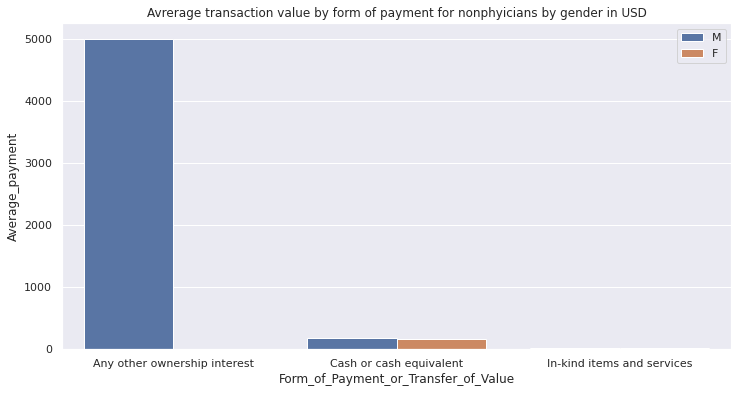

In [128]:
# Average transaction value by Form of payments.
g=sns.barplot(data=recip_avg_form[recip_avg_form['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'], x ='Form_of_Payment_or_Transfer_of_Value', y ='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title('Avrerage transaction value by form of payment for nonphyicians by gender in USD')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right');


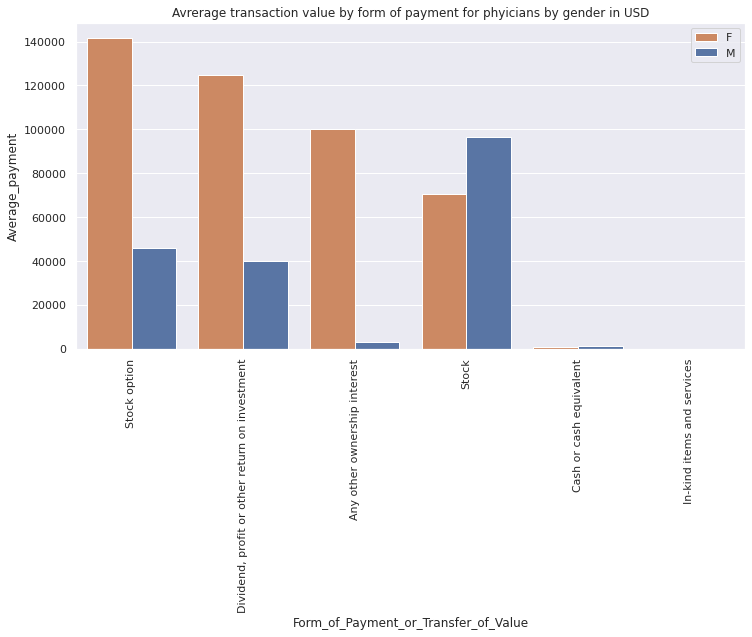

In [130]:
# Average transaction value by Form of payments.
g=sns.barplot(data=recip_avg_form[recip_avg_form['Covered_Recipient_Type']=='Covered Recipient Physician'], x ='Form_of_Payment_or_Transfer_of_Value', y ='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title('Avrerage transaction value by form of payment for phyicians by gender in USD')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right');
plt.xticks(rotation=90);

## Nature of payments

In [131]:
# Nature of payments and numer of payment records
df.Nature_of_Payment_or_Transfer_of_Value.value_counts()

Nature_of_Payment_or_Transfer_of_Value
Food and Beverage                                                                                                                                     13380946
Travel and Lodging                                                                                                                                      543987
Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program      236305
Consulting Fee                                                                                                                                          171464
Education                                                                                                                                               161097
Gift                                                                                                                                                     31785
Honorar

### Feature engineering 

In [132]:
## Converting long descritions to short
short_desc={'Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program':'Other_services',
            'Compensation for serving as faculty or as a speaker for a medical education program':'faculty_speaker_ed_prog',
            'Space rental or facility fees (teaching hospital only)':'Spacerent_teaching_hosp',
            'Long term medical supply or device loan':'Longterm_DeviceSupply_loan'}


In [133]:
# Converting using replace function and dict defined
df.Nature_of_Payment_or_Transfer_of_Value=df.Nature_of_Payment_or_Transfer_of_Value.replace(short_desc)


In [134]:
# Nature of payments and numer of payment records
print('Nature of payments and numer of payment records')
df.Nature_of_Payment_or_Transfer_of_Value.value_counts()


Nature of payments and numer of payment records


Nature_of_Payment_or_Transfer_of_Value
Food and Beverage             13380946
Travel and Lodging              543987
Other_services                  236305
Consulting Fee                  171464
Education                       161097
Gift                             31785
Honoraria                        20242
Royalty or License               15880
faculty_speaker_ed_prog          12238
Entertainment                     7967
Spacerent_teaching_hosp           7356
Longterm_DeviceSupply_loan        7353
Grant                             6170
Debt forgiveness                  5274
Acquisitions                       619
Charitable Contribution            550
Name: count, dtype: int64

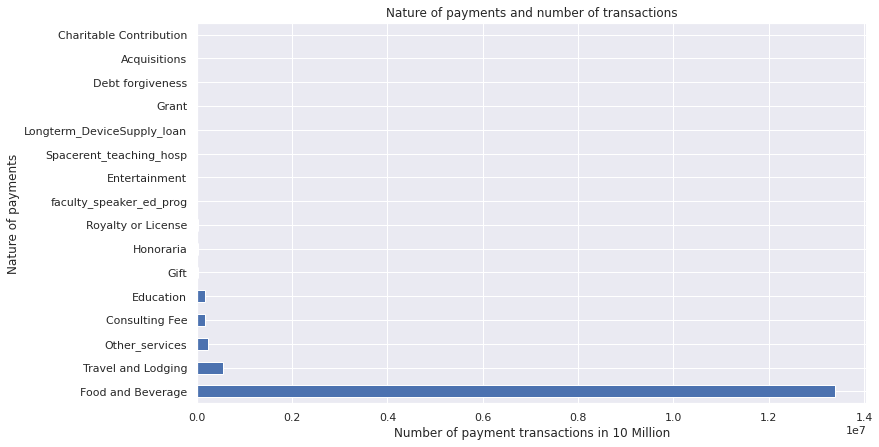

In [135]:
# Nature of payments and numer of payment records
plt.figure(figsize=(12,7))
plt.title('Nature of payments and number of transactions')
df['Nature_of_Payment_or_Transfer_of_Value'].value_counts().plot(kind='barh');
plt.xlabel("Number of payment transactions in 10 Million")
plt.ylabel("Nature of payments");


In [136]:
# Nature of payments and total payments to each type
print('Nature of payments and total amount of payments to each type')
df.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False)


Nature of payments and total amount of payments to each type


Nature_of_Payment_or_Transfer_of_Value
Royalty or License            1.192503e+09
Other_services                5.946490e+08
Consulting Fee                5.156993e+08
Food and Beverage             3.766124e+08
Travel and Lodging            1.793615e+08
Grant                         1.120433e+08
Acquisitions                  7.924858e+07
Education                     6.470559e+07
Honoraria                     5.591922e+07
Longterm_DeviceSupply_loan    2.984795e+07
Spacerent_teaching_hosp       2.907379e+07
faculty_speaker_ed_prog       2.870557e+07
Debt forgiveness              1.401473e+07
Charitable Contribution       7.485877e+06
Gift                          7.148187e+06
Entertainment                 1.027074e+06
Name: Total_Amount_of_Payment_USDollars, dtype: float64

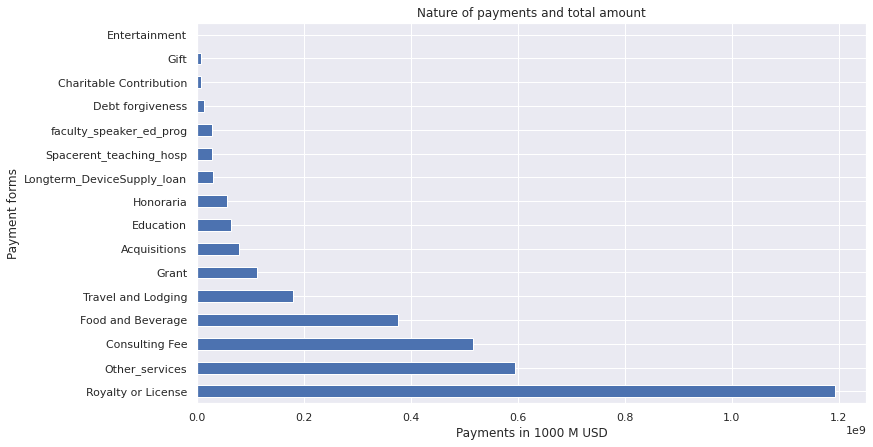

In [137]:
# Nature of payments and total payments to each type
plt.figure(figsize=(12,7))
plt.title('Nature of payments and total amount')
df.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Payments in 1000 M USD")
plt.ylabel("Payment forms");


In [138]:
# Nature of payments and average transaction value 
print('Nature of payments and average transaction value ')
df.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Average_payment'].mean().sort_values(ascending=False)


Nature of payments and average transaction value 


Nature_of_Payment_or_Transfer_of_Value
Acquisitions                  119663.792591
Royalty or License             74202.010297
Grant                          18138.996924
Charitable Contribution        13427.958836
Longterm_DeviceSupply_loan      3964.662558
Spacerent_teaching_hosp         3917.660111
Consulting Fee                  2925.029630
Debt forgiveness                2655.773078
Honoraria                       2599.868740
Other_services                  2490.718785
faculty_speaker_ed_prog         2213.161820
Education                        398.015922
Travel and Lodging               327.545170
Gift                             222.362489
Entertainment                     99.921787
Food and Beverage                 27.859879
Name: Average_payment, dtype: float64

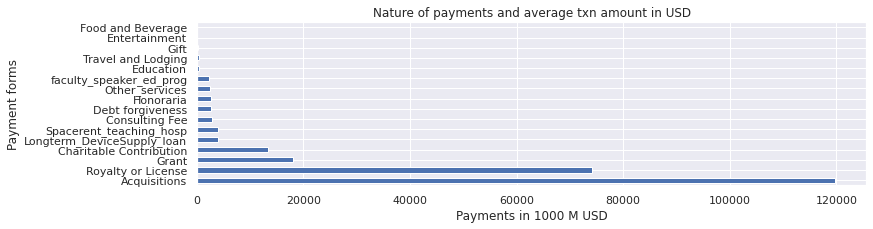

In [139]:
# Covered recipient types and average per transaction value for each type
plt.figure(figsize=(12,3))
plt.title('Nature of payments and average txn amount in USD')
df.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Average_payment'].mean().sort_values(ascending=False).plot(kind='barh');
plt.xlabel("Payments in 1000 M USD")
plt.ylabel("Payment forms");


In [140]:
# Nature of payments and average transaction value for recipient types
avg_nature=df.groupby(['Covered_Recipient_Type','Nature_of_Payment_or_Transfer_of_Value'])['Average_payment'].mean().reset_index()
avg_nature


,Covered_Recipient_Type,Nature_of_Payment_or_Transfer_of_Value,Average_payment
0,Covered Recipient Non-Physician Practitioner,Acquisitions,7511.204000
1,Covered Recipient Non-Physician Practitioner,Charitable Contribution,150.000000
2,Covered Recipient Non-Physician Practitioner,Consulting Fee,1320.902126
3,Covered Recipient Non-Physician Practitioner,Debt forgiveness,1128.997258
4,Covered Recipient Non-Physician Practitioner,Education,62.562226
5,Covered Recipient Non-Physician Practitioner,Entertainment,23.259462
6,Covered Recipient Non-Physician Practitioner,Food and Beverage,23.893205
7,Covered Recipient Non-Physician Practitioner,Gift,120.881060
8,Covered Recipient Non-Physician Practitioner,Grant,16383.068710
9,Covered Recipient Non-Physician Practitioner,Honoraria,1334.867915


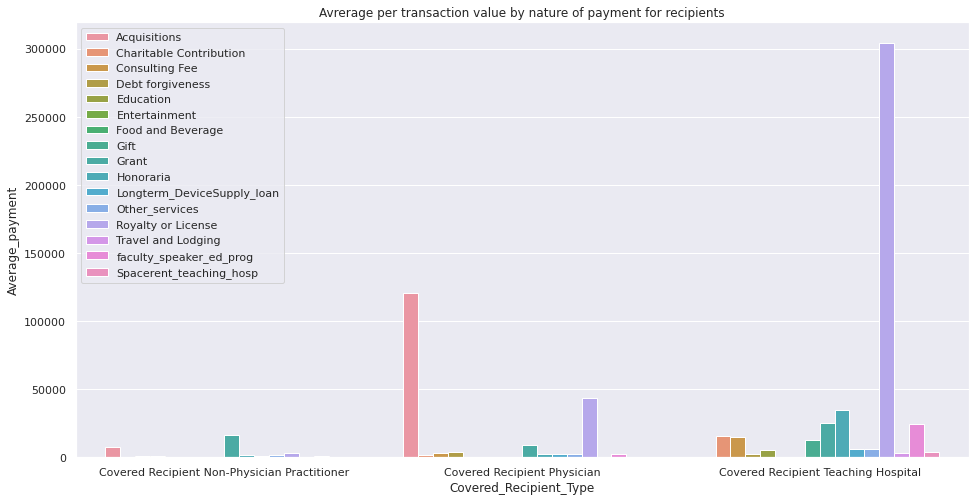

In [141]:
# Average per transaction value by nature of payments.
g=sns.barplot(data=avg_nature, x ='Covered_Recipient_Type', y ='Average_payment', 
              hue='Nature_of_Payment_or_Transfer_of_Value').set_title('Avrerage per transaction value by nature of payment for recipients')
g.figure.set_size_inches(16, 8)
plt.legend(loc='upper left');


In [142]:
# Nature of payments and average transaction value for recipient types
avg_nature_gender=df.groupby(['Covered_Recipient_Type','Nature_of_Payment_or_Transfer_of_Value', 'Covered_Recipient_gender'])['Average_payment'].mean().reset_index()
avg_nature_gender


,Covered_Recipient_Type,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Average_payment
0,Covered Recipient Non-Physician Practitioner,Acquisitions,F,8139.005000
1,Covered Recipient Non-Physician Practitioner,Acquisitions,M,7092.670000
2,Covered Recipient Non-Physician Practitioner,Charitable Contribution,F,150.000000
3,Covered Recipient Non-Physician Practitioner,Consulting Fee,F,1349.730490
4,Covered Recipient Non-Physician Practitioner,Consulting Fee,M,1232.579990
5,Covered Recipient Non-Physician Practitioner,Debt forgiveness,F,758.394898
6,Covered Recipient Non-Physician Practitioner,Debt forgiveness,M,2525.883077
7,Covered Recipient Non-Physician Practitioner,Education,F,62.156828
8,Covered Recipient Non-Physician Practitioner,Education,M,64.272518
9,Covered Recipient Non-Physician Practitioner,Entertainment,F,24.415298


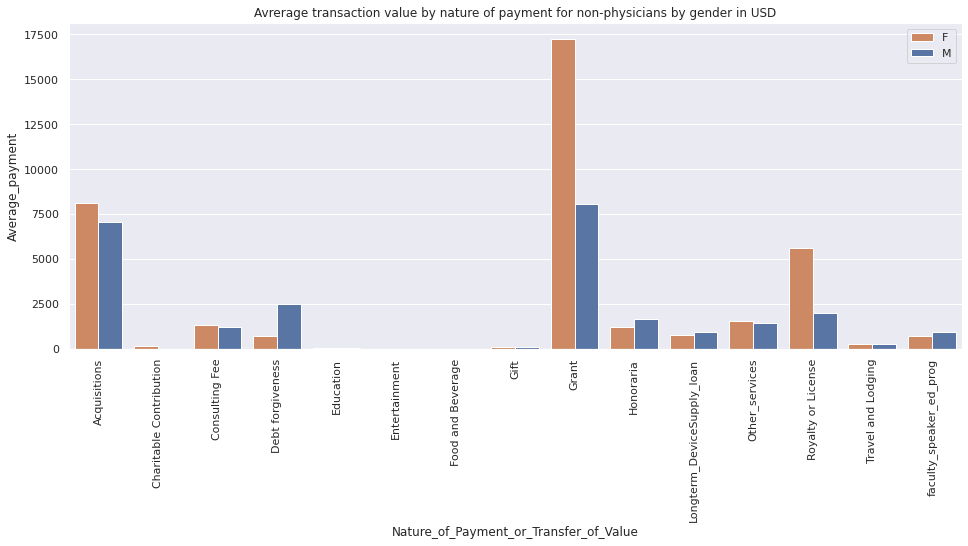

In [144]:
# Average per transaction value by nature of payments for non physicians.
g=sns.barplot(data=avg_nature_gender[avg_nature_gender['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'], x ='Nature_of_Payment_or_Transfer_of_Value', y ='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title('Avrerage transaction value by nature of payment for non-physicians by gender in USD')
g.figure.set_size_inches(16, 6)
plt.xticks(rotation=90)
plt.legend(loc='upper right');


In [145]:
# Nature of payments and total payment for recipient types
print('Nature of payments and total payment for recipient types')
tot_nature=df.groupby(['Covered_Recipient_Type','Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().reset_index()
tot_nature


Nature of payments and total payment for recipient types


,Covered_Recipient_Type,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,Acquisitions,3.755602e+04
1,Covered Recipient Non-Physician Practitioner,Charitable Contribution,7.500000e+02
2,Covered Recipient Non-Physician Practitioner,Consulting Fee,1.302129e+07
3,Covered Recipient Non-Physician Practitioner,Debt forgiveness,6.999783e+04
4,Covered Recipient Non-Physician Practitioner,Education,2.611345e+06
5,Covered Recipient Non-Physician Practitioner,Entertainment,5.186860e+03
6,Covered Recipient Non-Physician Practitioner,Food and Beverage,1.156297e+08
7,Covered Recipient Non-Physician Practitioner,Gift,6.291957e+04
8,Covered Recipient Non-Physician Practitioner,Grant,5.078751e+05
9,Covered Recipient Non-Physician Practitioner,Honoraria,1.808855e+06


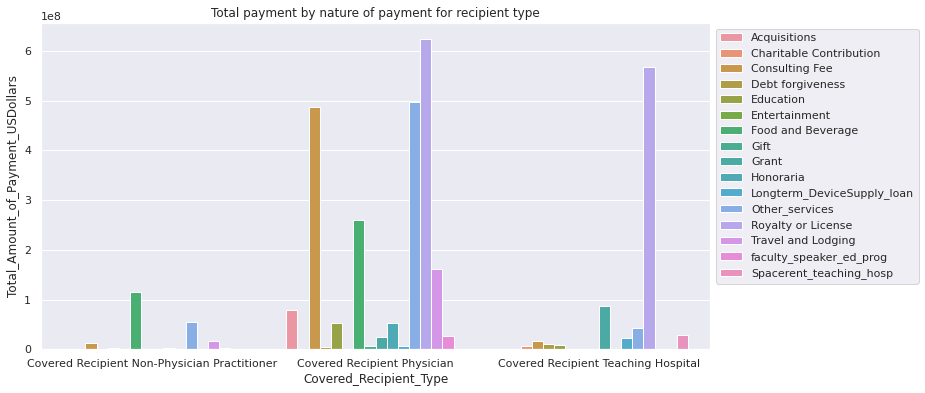

In [146]:
# Total payment by nature of payments to recipients.
g=sns.barplot(data=tot_nature, x ='Covered_Recipient_Type', y ='Total_Amount_of_Payment_USDollars', hue='Nature_of_Payment_or_Transfer_of_Value').set_title('Total payment by nature of payment for recipient type')
g.figure.set_size_inches(12, 6)
plt.legend(bbox_to_anchor=(1,1),loc='upper left');


In [147]:
# Total payment by nature of payment Entertainment
phys_tot_nature_entertainment=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Entertainment')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_entertainment


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,586850.0,M,5820.84
1,191865.0,M,5742.65
2,341012.0,M,5022.73
3,1333746.0,M,4981.78
4,398247.0,M,4866.67
...,...,...,...
5172,132712.0,M,6.86
5173,2789331.0,M,6.21
5174,344120.0,M,5.95
5175,353997.0,M,5.50


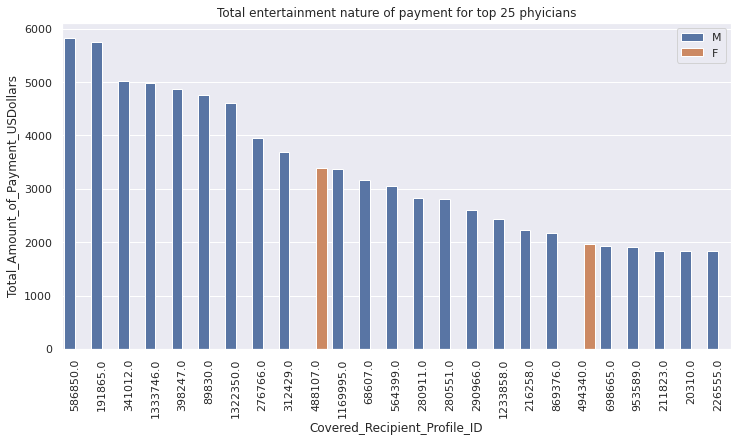

In [148]:
# dividends, profits or other roi.
g=sns.barplot(data=phys_tot_nature_entertainment[:25], x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_entertainment[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total entertainment nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [149]:
# Total payment by nature of payment Entertainment
phys_tot_nature_charitable=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Charitable Contribution')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_charitable


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,199929.0,M,30000.00
1,66489.0,M,25000.00
2,10204152.0,M,16155.00
3,722357.0,M,10648.62
4,288407.0,M,10000.00
...,...,...,...
61,1108410.0,M,21.86
62,418683.0,F,21.56
63,755285.0,F,17.37
64,467427.0,M,17.37


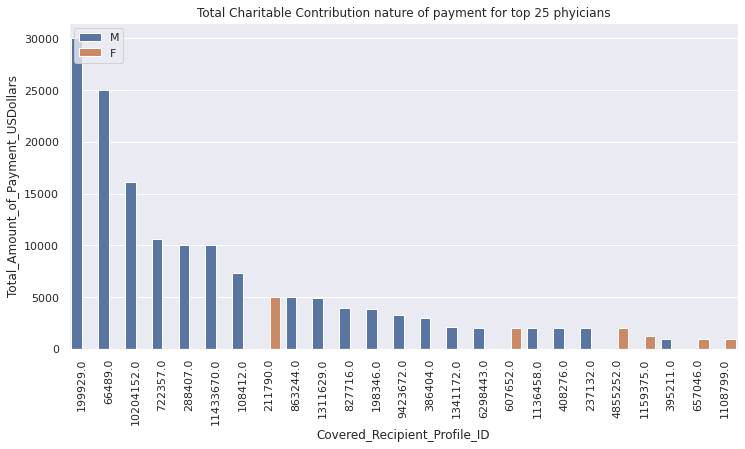

In [150]:
# total charitable charitable contributions
g=sns.barplot(data=phys_tot_nature_charitable[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_charitable[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total Charitable Contribution nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper left')
plt.xticks(rotation=90);


In [151]:
# Total payment by nature of payment Entertainment
phys_tot_nature_acquisitions=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Acquisitions')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_acquisitions


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,559457.0,M,7322804.93
1,187955.0,M,4846659.06
2,46018.0,M,3944327.67
3,68860.0,M,3644558.02
4,514127.0,M,3464973.72
...,...,...,...
391,426693.0,M,244.79
392,295683.0,M,211.92
393,926967.0,M,177.67
394,121198.0,M,115.01


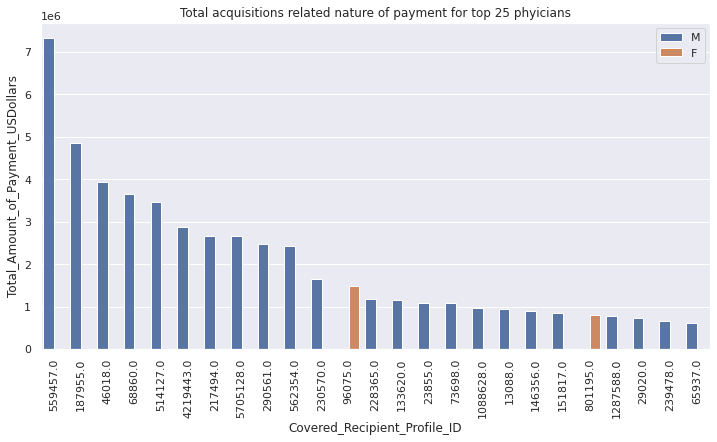

In [152]:
# cquitions nature of total payments
g=sns.barplot(data=phys_tot_nature_acquisitions[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_acquisitions[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total acquisitions related nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [153]:
# Total payment by consulting fee nature of payment 
phys_tot_nature_Consulting=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Consulting Fee')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Consulting


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,593764.0,M,3885915.00
1,1286944.0,M,2440546.74
2,1050699.0,M,1258594.35
3,20132.0,M,1133237.31
4,273699.0,M,1041200.00
...,...,...,...
35035,89249.0,F,8.49
35036,144435.0,M,8.00
35037,124411.0,M,7.86
35038,653206.0,F,7.42


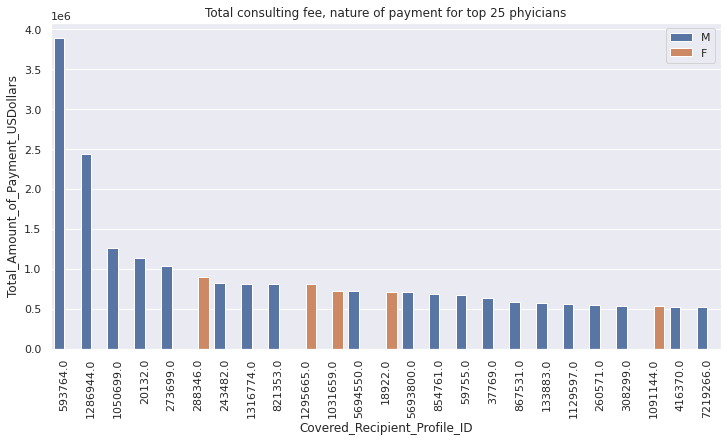

In [154]:
# Total consulting fee by nture of payments for physicians
g=sns.barplot(data=phys_tot_nature_Consulting[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_Consulting[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total consulting fee, nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [155]:
# Total payment debt forgiveness by nature of payment Entertainment
phys_tot_nature_Debt_forgiveness=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Debt forgiveness')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Debt_forgiveness


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,999662.0,F,242782.50
1,128072.0,M,200656.95
2,255552.0,M,165096.84
3,427666.0,M,118661.56
4,574017.0,F,97716.95
...,...,...,...
834,2783440.0,M,12.53
835,906694.0,F,9.99
836,29846.0,M,9.88
837,680073.0,M,3.61


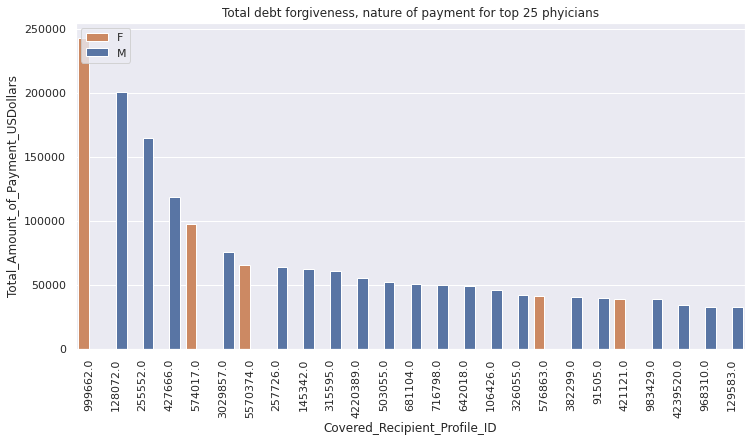

In [156]:
# dividends, profits or other roi.
g=sns.barplot(data=phys_tot_nature_Debt_forgiveness[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_Debt_forgiveness[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total debt forgiveness, nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper left')
plt.xticks(rotation=90);


In [157]:
# Total payment by nature of payment Education
phys_tot_nature_Education=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Education')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Education


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,308237.0,M,227900.00
1,1039543.0,M,210250.00
2,1277877.0,M,182900.00
3,35908.0,M,181149.76
4,359889.0,M,161550.00
...,...,...,...
66734,610399.0,M,0.35
66735,60497.0,F,0.35
66736,60796.0,M,0.35
66737,717754.0,F,0.35


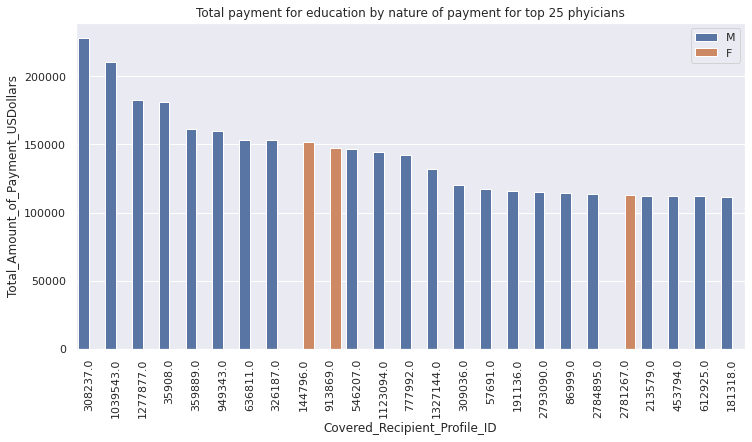

In [158]:
# total payment Education, nature of payment
g=sns.barplot(data=phys_tot_nature_Education[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Education[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for education by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [159]:
# Total payment by nature of payment food & beverage
phys_tot_nature_FnB=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Food and Beverage')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_FnB


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,556778.0,F,79494.37
1,748897.0,M,67011.98
2,192183.0,M,63289.84
3,350518.0,M,63247.36
4,1214560.0,M,60822.78
...,...,...,...
605118,9672070.0,M,0.84
605119,292741.0,F,0.84
605120,1080708.0,F,0.84
605121,986221.0,M,0.56


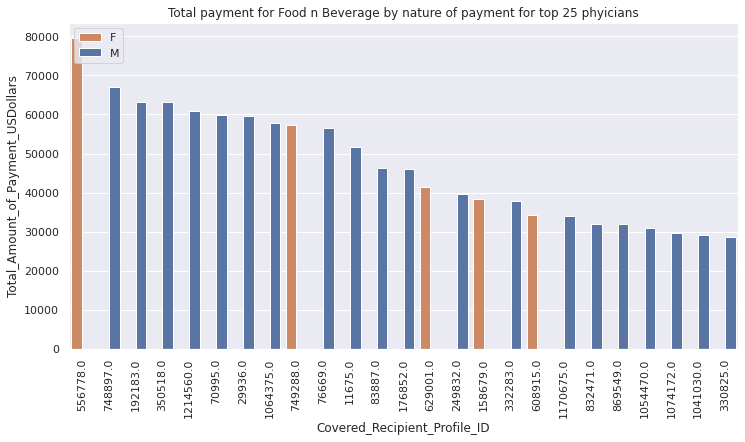

In [160]:
# total payment food nd beverage, nature of payment
g=sns.barplot(data=phys_tot_nature_FnB[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_FnB[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total payment for Food n Beverage by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper left')
plt.xticks(rotation=90);


In [161]:
# Total payment by nature of payment gift
phys_tot_nature_Gift=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Gift')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Gift


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,753470.0,M,224640.00
1,15324.0,M,220800.00
2,64039.0,M,148980.00
3,229366.0,M,114049.76
4,300715.0,M,83083.00
...,...,...,...
14852,122844.0,M,1.56
14853,286060.0,M,0.90
14854,86394.0,M,0.77
14855,224533.0,F,0.72


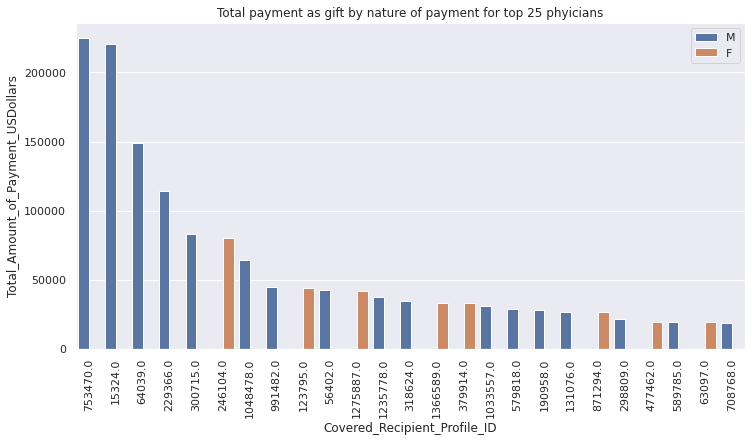

In [162]:
# total payment gift, nature of payment
g=sns.barplot(data=phys_tot_nature_Gift[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Gift[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment as gift by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [163]:
# Total payment by nature of payment grant
# total payment faculty_speaker_ed_prog, nature of payment
phys_tot_nature_Grant=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Grant')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Grant


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,284719.0,M,400000.00
1,250516.0,M,176419.56
2,487161.0,M,154500.00
3,3295468.0,M,146813.20
4,11342088.0,F,140000.00
...,...,...,...
1958,9455123.0,M,16.19
1959,996954.0,M,15.59
1960,1284300.0,F,15.06
1961,1562508.0,F,14.85


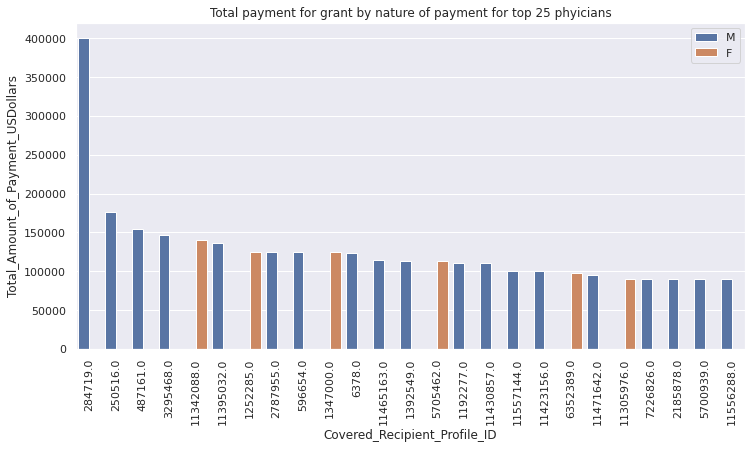

In [164]:
# total payment grants, nature of payment
g=sns.barplot(data=phys_tot_nature_Grant[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              order=phys_tot_nature_Grant[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              hue='Covered_Recipient_gender', palette=my_palette).set_title('Total payment for grant by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [165]:
# Total payment Honoraria by nature of payment Education
phys_tot_nature_Honoraria=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Honoraria')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Honoraria


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,315220.0,M,1113510.00
1,33129.0,M,788061.04
2,73386.0,M,386988.62
3,335384.0,M,373456.48
4,43894.0,F,277500.00
...,...,...,...
6799,8018185.0,F,10.74
6800,365753.0,M,9.65
6801,4441860.0,M,9.47
6802,129278.0,F,8.18


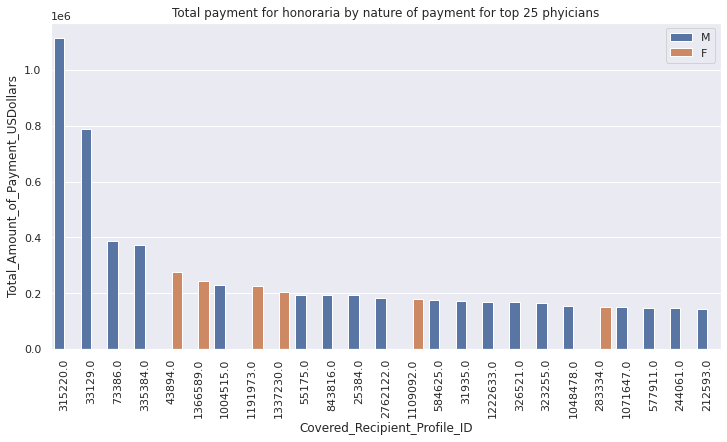

In [166]:
# total payment Honoraria, nature of payment
g=sns.barplot(data=phys_tot_nature_Honoraria[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Honoraria[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for honoraria by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [167]:
# Total payment Longterm_DeviceSupply_loan by nature of payment Education
phys_tot_nature_dev_supply_loan=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Longterm_DeviceSupply_loan')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_dev_supply_loan


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,62070.0,M,150000.00
1,557911.0,M,101837.36
2,180296.0,M,90000.00
3,358375.0,M,86883.34
4,2777648.0,M,70083.34
...,...,...,...
1777,1028009.0,F,18.36
1778,561231.0,F,18.36
1779,7233353.0,M,14.18
1780,321011.0,F,13.59


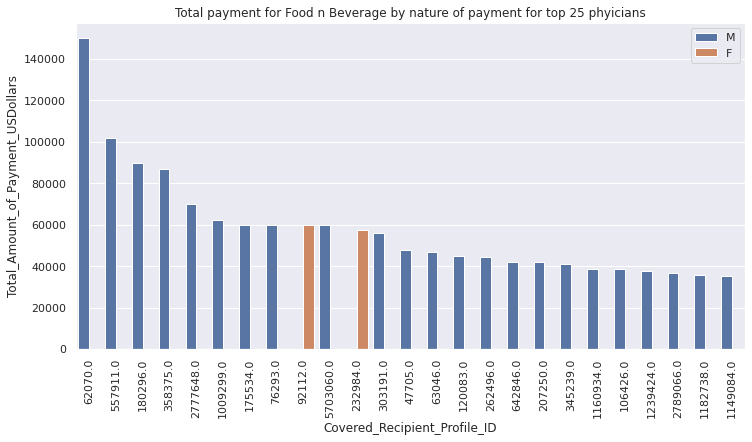

In [168]:
# total payment Longterm_DeviceSupply_loan, nature of payment
g=sns.barplot(data=phys_tot_nature_dev_supply_loan[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_dev_supply_loan[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for Food n Beverage by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [169]:
# Total payment Other_services by nature of payment Education
phys_tot_nature_Other_services=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Other_services')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Other_services


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,1032575.0,M,1967158.97
1,67491.0,M,1880210.29
2,1389265.0,M,892700.15
3,1319821.0,M,806828.04
4,232968.0,M,803233.00
...,...,...,...
24114,1264377.0,M,5.30
24115,540574.0,F,5.20
24116,232626.0,M,5.00
24117,662442.0,F,4.00


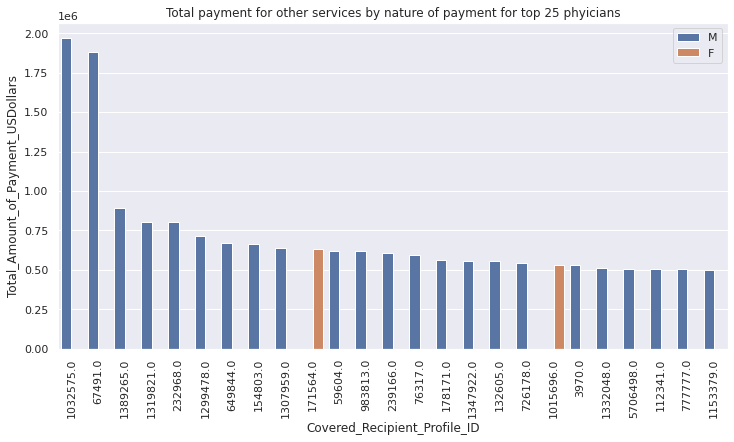

In [170]:
# total payment Other_services, nature of payment
g=sns.barplot(data=phys_tot_nature_Other_services[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Other_services[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for other services by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [171]:
# Total payment Royalty or License by nature of payment Education
phys_tot_nature_Royalty=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Royalty


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,288926.0,M,33922024.93
1,1166415.0,M,29433942.06
2,311622.0,M,17296899.00
3,105583.0,M,16065515.51
4,1141140.0,M,11600124.00
...,...,...,...
2448,66402.0,M,24.57
2449,313334.0,M,24.20
2450,188496.0,M,24.20
2451,199974.0,M,21.92


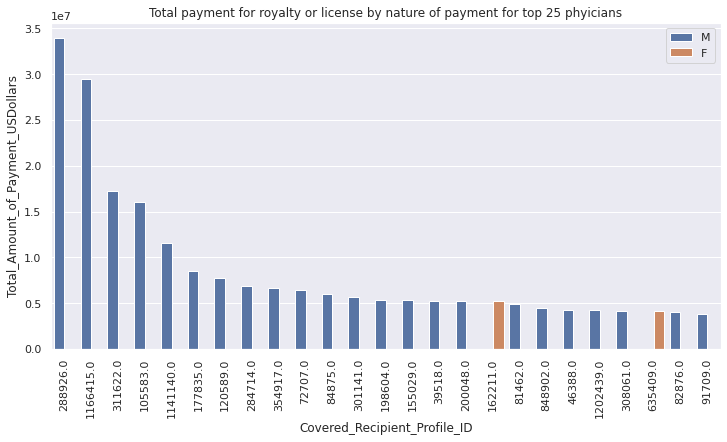

In [172]:
# total payment Royalty or License, nature of payment
g=sns.barplot(data=phys_tot_nature_Royalty[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Royalty[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for royalty or license by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [173]:
# Total payment by Travel and Lodging nature of payment Education
phys_tot_nature_Travel=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Travel and Lodging')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_Travel


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,1040463.0,M,213561.29
1,1299478.0,M,175601.72
2,66489.0,M,168690.51
3,295661.0,M,153743.16
4,842804.0,F,149902.34
...,...,...,...
61134,1040725.0,M,1.09
61135,109050.0,M,0.77
61136,1336272.0,F,0.77
61137,4227554.0,M,0.42


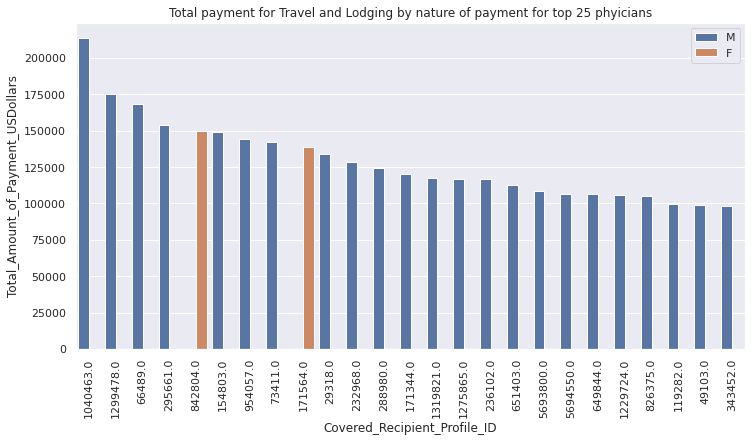

In [174]:
# total payment food nd beverage, nature of payment
g=sns.barplot(data=phys_tot_nature_Travel[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_Travel[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for Travel and Lodging by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [175]:
# Total payment by faculty_speaker_ed_prog nature of payment Education
phys_tot_nature_faculty_ed=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='faculty_speaker_ed_prog')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_faculty_ed


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,872661.0,M,542500.00
1,333494.0,M,396500.00
2,494345.0,M,389897.13
3,25477.0,M,345508.99
4,49302.0,M,288025.77
...,...,...,...
2877,1833443.0,F,17.86
2878,5773723.0,M,17.86
2879,716465.0,F,17.86
2880,1295507.0,F,17.78


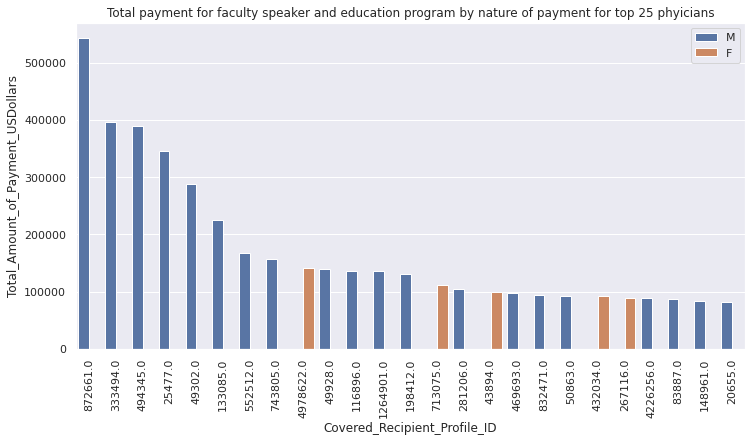

In [176]:
# total payment faculty_speaker_ed_prog, nature of payment
g=sns.barplot(data=phys_tot_nature_faculty_ed[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=phys_tot_nature_faculty_ed[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for faculty speaker and education program by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [177]:
# Total payment Spacerent teaching hospital by nature of payment Education
phys_tot_nature_space_rent=df[(df['Covered_Recipient_Type']=='Covered Recipient Physician')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Spacerent_teaching_hosp')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
phys_tot_nature_space_rent


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars


## Non physicians nature of payments

In [178]:
# Total payment by nature of payment Entertainment
nonphys_tot_nature_entertainment=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Entertainment')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_entertainment


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10898779.0,F,1226.84
1,10624255.0,M,88.18
2,10601027.0,F,75.07
3,519057.0,F,54.66
4,10924497.0,F,47.87
...,...,...,...
189,11237026.0,F,12.90
190,10544827.0,F,12.90
191,10908801.0,F,12.81
192,11174621.0,M,12.81


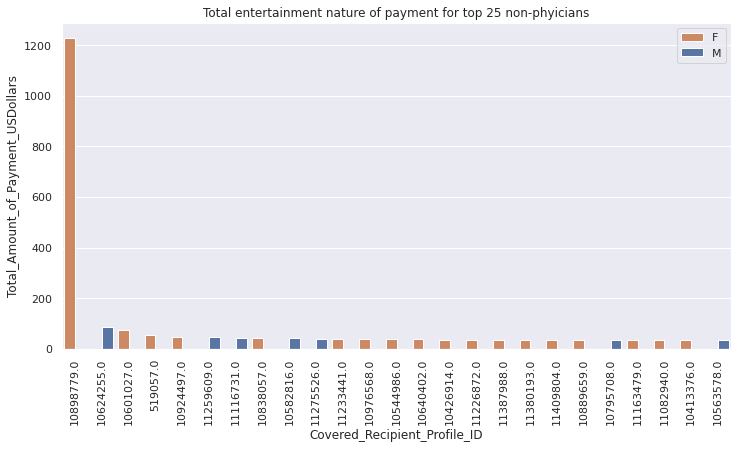

In [179]:
# dividends, profits or other roi.
g=sns.barplot(data=nonphys_tot_nature_entertainment[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_entertainment[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total entertainment nature of payment for top 25 non-phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [180]:
# Total payment by nature of payment Entertainment
nonphys_tot_nature_charitable=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Charitable Contribution')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_charitable



,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10693537.0,F,600.0
1,11237862.0,F,150.0


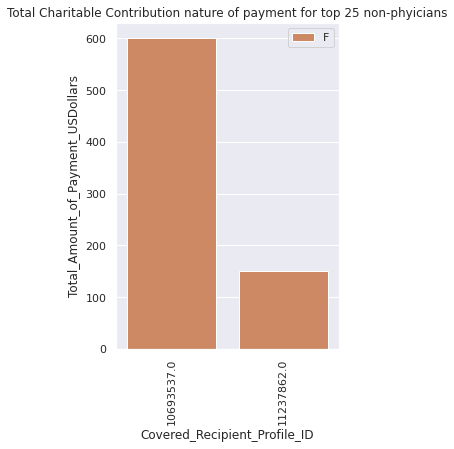

In [181]:
# total charitable charitable contributions
g=sns.barplot(data=nonphys_tot_nature_charitable[:25], x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title('Total Charitable Contribution nature of payment for top 25 non-phyicians')
g.figure.set_size_inches(4, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [182]:

# Total payment by nature of payment Aquisitions
nonphys_tot_nature_acquisitions=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Acquisitions')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_acquisitions


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10468540.0,M,16278.01
1,11020047.0,F,16278.01
2,10695783.0,M,5000.00


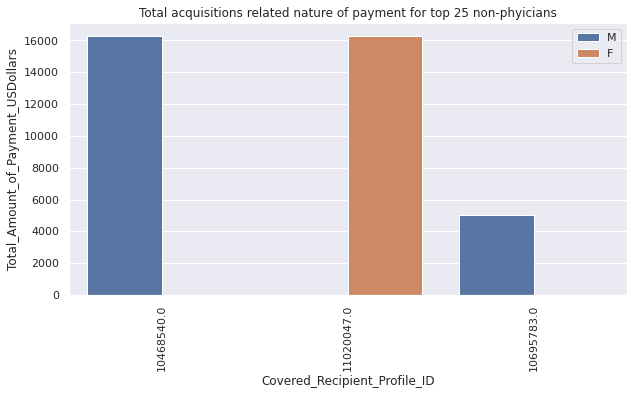

In [183]:
# acquitions nature of total payments
g=sns.barplot(data=nonphys_tot_nature_acquisitions[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_acquisitions[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total acquisitions related nature of payment for top 25 non-phyicians')
g.figure.set_size_inches(10, 5)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [184]:
# Total payment by consulting fee nature of payment 
nonphys_tot_nature_Consulting=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Consulting Fee')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Consulting


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,11117942.0,F,180700.00
1,11158876.0,F,178468.20
2,11480469.0,F,170411.11
3,10732309.0,F,102525.00
4,11153301.0,F,100186.81
...,...,...,...
3443,11194123.0,F,12.74
3444,10580350.0,M,12.50
3445,10939110.0,F,9.71
3446,10877010.0,F,9.49


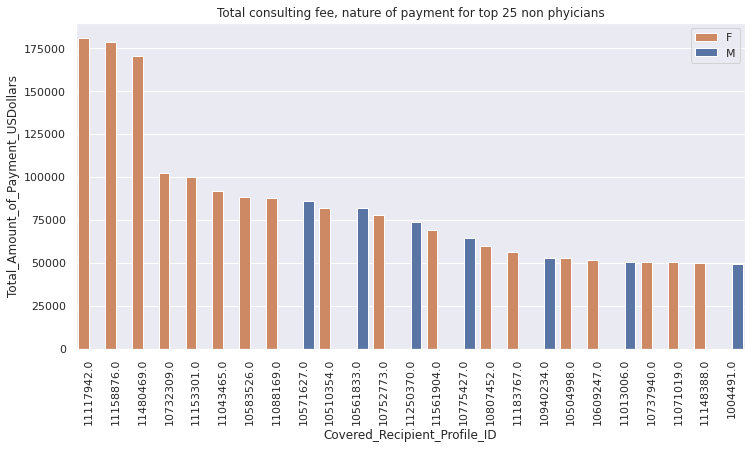

In [185]:
# Total consulting fee by nture of payments for non physicians
g=sns.barplot(data=nonphys_tot_nature_Consulting[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Consulting[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total consulting fee, nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [186]:
# Total payment debt forgiveness by nature of payment Entertainment
nonphys_tot_nature_Debt_forgiveness=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Debt forgiveness')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Debt_forgiveness


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10561822.0,M,27089.56
1,5690802.0,F,24384.56
2,11226925.0,F,5400.00
3,10531886.0,M,5270.00
4,10978895.0,F,3202.50
...,...,...,...
56,11075855.0,F,16.46
57,11071107.0,F,16.46
58,10908906.0,M,16.46
59,10754197.0,M,16.46


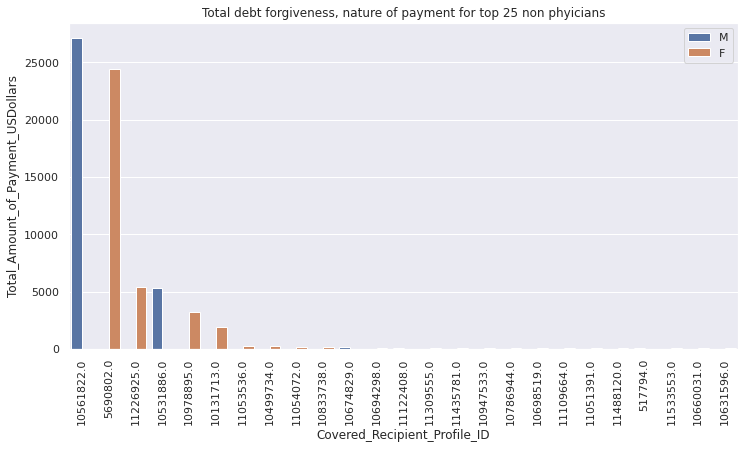

In [187]:
# dividends, profits or other roi.
g=sns.barplot(data=nonphys_tot_nature_Debt_forgiveness[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Debt_forgiveness[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total debt forgiveness, nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [188]:
# Total payment by nature of payment Education
nonphys_tot_nature_Education=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Education')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Education


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10559989.0,M,22500.00
1,10442899.0,F,21150.00
2,11112989.0,F,16018.67
3,11131816.0,F,15300.00
4,11250370.0,M,11417.18
...,...,...,...
26598,10742815.0,F,0.35
26599,196657.0,F,0.35
26600,11110064.0,F,0.35
26601,11026283.0,F,0.15


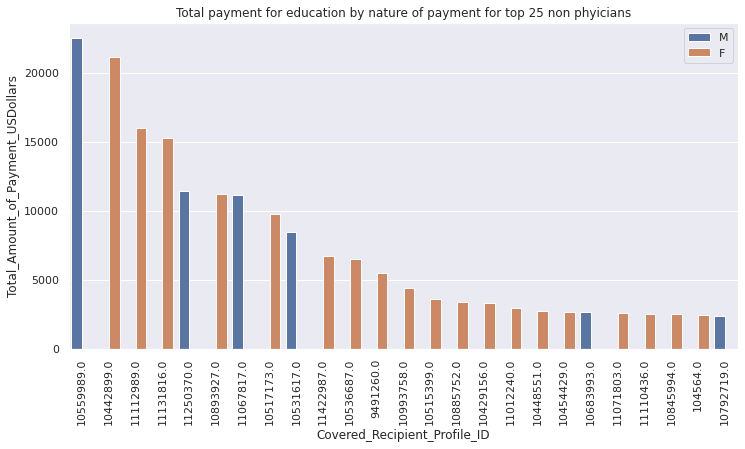

In [189]:
# total payment Education, nature of payment
g=sns.barplot(data=nonphys_tot_nature_Education[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Education[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for education by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [190]:
# Total payment by nature of payment food & beverage
nonphys_tot_nature_FnB=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Food and Beverage')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_FnB



,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10644036.0,F,29187.07
1,10910432.0,F,18208.43
2,129023.0,F,15979.15
3,10670806.0,F,14941.20
4,11206485.0,F,14567.50
...,...,...,...
306974,10607098.0,M,1.62
306975,10912681.0,F,1.62
306976,10432599.0,F,1.53
306977,11278283.0,M,1.33


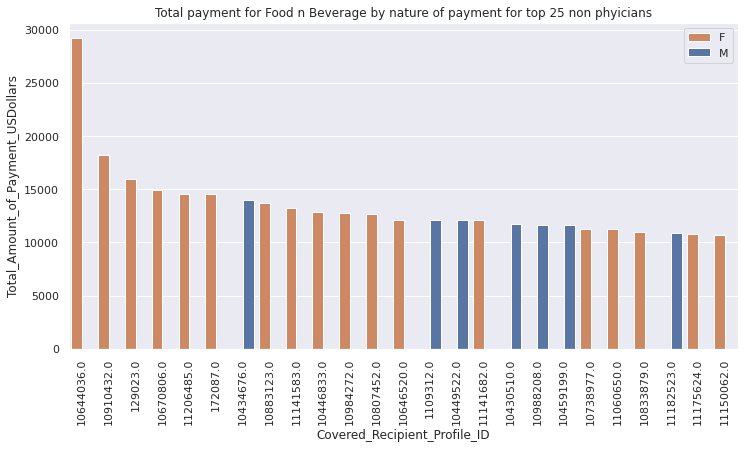

In [191]:
# total payment food nd beverage, nature of payment
g=sns.barplot(data=nonphys_tot_nature_FnB[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_FnB[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for Food n Beverage by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [192]:
# Total payment by nature of payment gift
nonphys_tot_nature_Gift=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Gift')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Gift


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10509722.0,F,8483.04
1,7224544.0,F,5655.36
2,10430266.0,F,5467.06
3,10869729.0,F,5216.68
4,10917541.0,F,4489.20
...,...,...,...
256,10980064.0,M,10.49
257,11000235.0,F,10.14
258,10848320.0,F,3.53
259,11266526.0,M,1.87


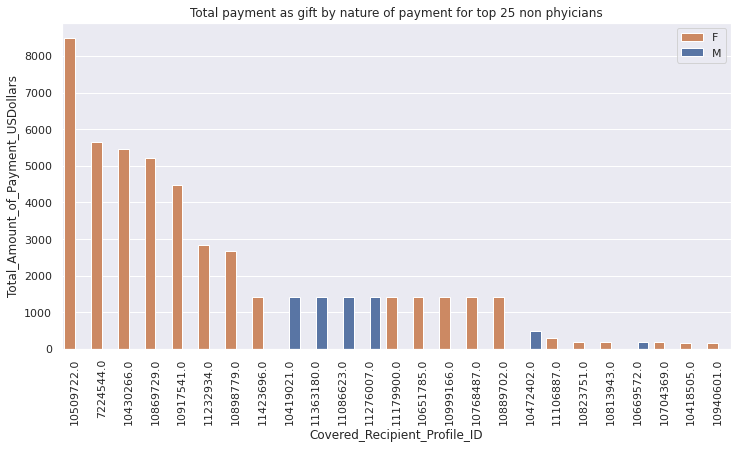

In [193]:
# total payment gift, nature of payment
g=sns.barplot(data=nonphys_tot_nature_Gift[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Gift[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment as gift by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [194]:
# Total payment by nature of payment grant
nonphys_tot_nature_Grant=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Grant')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Grant


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10761568.0,F,200000.00
1,10929936.0,F,131419.56
2,10841076.0,F,47500.00
3,10580520.0,F,47500.00
4,10568582.0,F,25000.00
5,11560474.0,M,19000.00
6,10653489.0,F,15190.00
7,10666912.0,F,10000.00
8,11067817.0,M,5000.00
9,11244245.0,F,3500.00


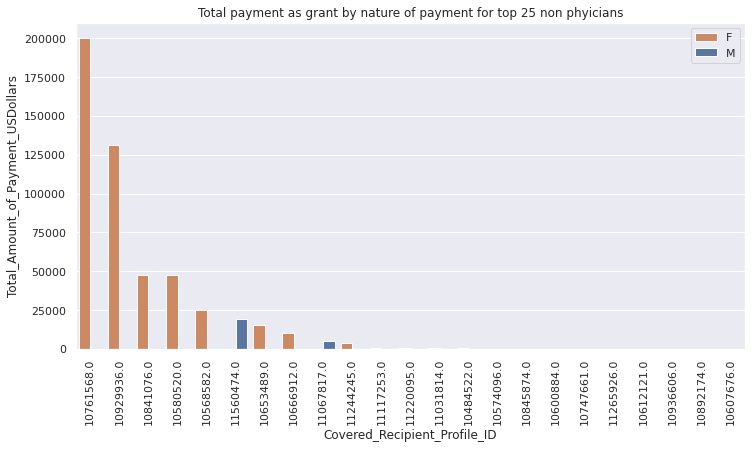

In [195]:
# total payment gift, nature of payment
g=sns.barplot(data=nonphys_tot_nature_Grant[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Grant[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment as grant by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [196]:
# Total payment Honoraria by nature of payment Education
nonphys_tot_nature_Honoraria=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Honoraria')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Honoraria


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,11118894.0,M,79000.0
1,10873726.0,F,72648.0
2,10752422.0,F,66112.5
3,11135817.0,M,42400.0
4,10869790.0,F,28760.0
...,...,...,...
453,10638269.0,F,50.0
454,10492486.0,F,50.0
455,10508958.0,F,25.0
456,4320852.0,F,25.0


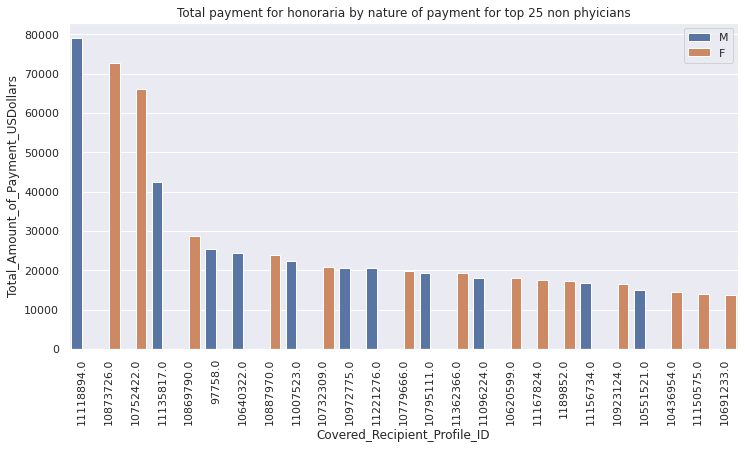

In [197]:
# total payment Honoraria, nature of payment
g=sns.barplot(data=nonphys_tot_nature_Honoraria[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Honoraria[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for honoraria by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [198]:
# Total payment Longterm_DeviceSupply_loan by nature of payment Education
nonphys_tot_nature_dev_supply_loan=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Longterm_DeviceSupply_loan')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_dev_supply_loan


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10746771.0,F,51397.50
1,5162140.0,F,27500.00
2,10987259.0,F,15000.00
3,10414891.0,F,15000.00
4,10712773.0,F,15000.00
...,...,...,...
341,10726494.0,F,25.05
342,10693507.0,M,25.05
343,11212590.0,F,19.98
344,11143229.0,F,19.98


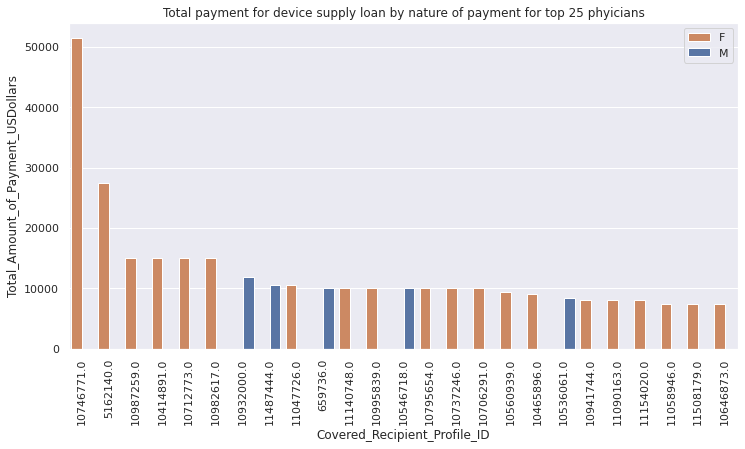

In [199]:
# total payment Longterm_DeviceSupply_loan, nature of payment
g=sns.barplot(data=nonphys_tot_nature_dev_supply_loan[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_dev_supply_loan[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for device supply loan by nature of payment for top 25 phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [200]:
# Total payment Other_services by nature of payment Education
nonphys_tot_nature_Other_services=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='Other_services')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_Other_services



,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,11222565.0,M,414722.50
1,11175624.0,F,360115.00
2,10459199.0,M,314599.50
3,10430510.0,M,304190.38
4,11513223.0,F,300660.00
...,...,...,...
3432,10951798.0,F,13.25
3433,10763926.0,F,13.25
3434,11020150.0,F,13.25
3435,10471574.0,F,9.00


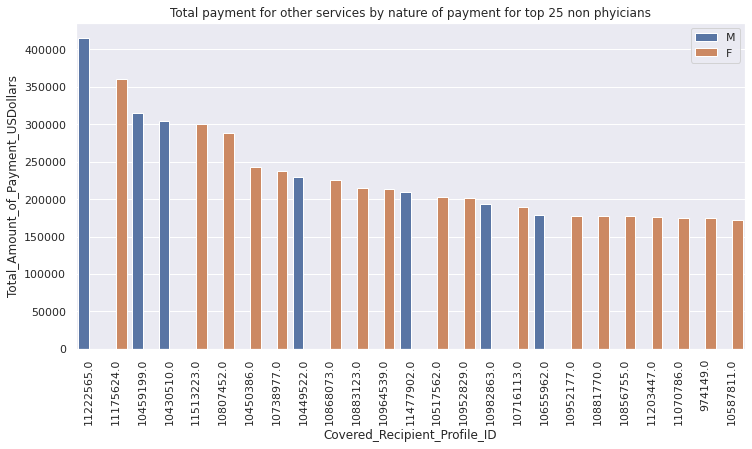

In [201]:
# total payment Other_services, nature of payment
g=sns.barplot(data=nonphys_tot_nature_Other_services[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_Other_services[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for other services by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [202]:
# Total payment by faculty_speaker_ed_prog nature of payment Education
nonphys_tot_nature_faculty_ed=df[(df['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner')&(df['Nature_of_Payment_or_Transfer_of_Value']=='faculty_speaker_ed_prog')].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nonphys_tot_nature_faculty_ed


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,10968492.0,F,66967.76
1,10496647.0,F,58830.00
2,10967936.0,F,42718.98
3,11430772.0,F,37283.12
4,970482.0,F,34650.30
...,...,...,...
411,10872417.0,M,107.15
412,7917988.0,F,94.66
413,10575547.0,F,94.66
414,10779349.0,F,93.01


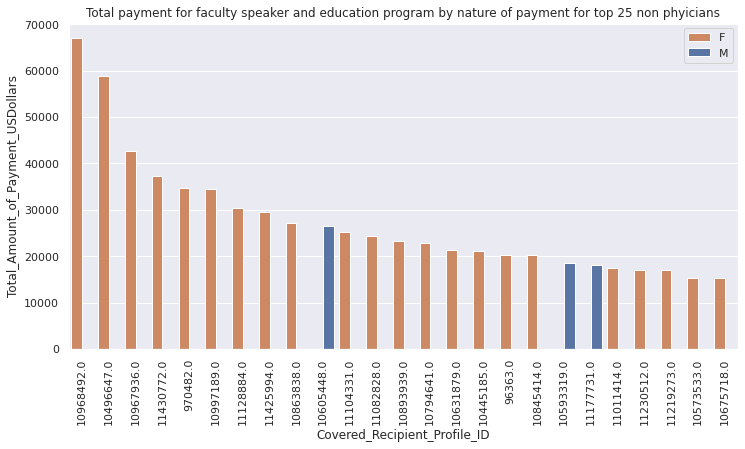

In [203]:
# total payment faculty_speaker_ed_prog, nature of payment
g=sns.barplot(data=nonphys_tot_nature_faculty_ed[:25], 
              x ='Covered_Recipient_Profile_ID', y ='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender', 
              order=nonphys_tot_nature_faculty_ed[:25].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID,
              palette=my_palette).set_title('Total payment for faculty speaker and education program by nature of payment for top 25 non phyicians')
g.figure.set_size_inches(12, 6)
plt.legend(loc='upper right')
plt.xticks(rotation=90);


In [205]:
df.to_csv("Dooit_top_level_general_features_avg_NatureOfGift")


### CSV has two columns Average transaction values, nature of gifts shortended names.

### CSV to be used for segmentation and further company level analysis on dashboard.